# deskbird Growth Analysis

End-to-end analysis connecting paid ads, CRM pipeline, and product usage data to define growth metrics and surface actionable insights.

## Table of Contents

- 1. Setup
  - Imports
  - Load Raw Data
- 2. Data Overview
  - CRM Pipeline
  - Paid Ads
  - Product Usage Events
- 3. Data Quality & Assumptions
  - Paid Ads — grain: one row per campaign per day
  - Product Usage Events — grain: one row per event
  - CRM Pipeline — grain: one row per lead
  - Verifying Assumptions
    - 1. Finding: `company_name` is the true account key, not `company_id`
    - 2. Finding: repeat leads over time, not regional branches
    - 3. Finding: unattributed leads are bucketed, not dropped
    - 4. Finding: referential integrity is clean — safe as inner joins
    - 5. Finding: usage data exists only for accounts that started a trial
    - 6. Data Quality Issue: usage events continue after trial end for non-converted accounts
    - 7. Finding: chronological ordering holds, except 6 already-known rows
    - 8. Finding: trial length is a hard 14-day constraint, zero exceptions
  - Assumptions Summary
  - Caveats & Data Limitations
    - `amount` does not scale with account size
    - `plan_tier` and `seats_used` appear to be randomly assigned per event, not persistent state
- 4. Build the Cleaned, Joined Dataset
- 5. The 5 Metrics
  - Metric 1: CAC — Blended + by Channel
  - Metric 2: Funnel Conversion Rate
  - Metric 3: LTV:CAC by Channel
  - Metric 4: Cost Per Lead (CPL) by Channel
  - Metric 5: Retention / Churn Rate
- 6. Exploratory Insights
  - Acquisition (Paid Ads)
    - Additional Paid Ads views
  - Conversion (CRM)
    - First-Touch vs. Eventual Lead Qualification
    - Lead Volume Over Time, and Leads per Company
    - Sales Cycle Length, and Judging the "Stalled" Leads
  - Retention (Product Usage + Cohort Analysis)
    - Product Usage Charts
    - Two More: Distinct Companies Over Time, and by Eventual Outcome
    - Exploring Retention: Cohort Analysis (Preview)
  - Advanced Analysis (Optional)
    - Statistically Defining "Dormant": Kaplan-Meier Survival Analysis
    - Enhanced Funnel: Splitting "Stalled" into Dormant vs. Still Active
    - Propensity Model: Win/Loss Prediction and Dormant Reactivation Scoring
- 7. Data Model
  - Sources
  - Staging
  - Intermediate
  - Snapshot (SCD Type 2)
  - Dimensions
  - Facts
  - Marts + Semantic Layer
  - Tests: Error vs. Warning
- 8. Recommendations
  - Sales & CRM Process
    - 1. Split the 119-Day Cutoff Into Two Tracks
    - 2. Standardize How `amount` Gets Entered Into the CRM
  - Marketing & Acquisition
    - 3. Do Not Shift Budget Toward Display Without an Incrementality Test First
    - 4. Fix Paid Search's Cost Problem at the Bidding Level, Not Targeting
  - Retention
    - 5. Invest Retention Effort in the First Quarter Post-Close
    - 6. Revisit Churn/LTV Numbers Once Censoring Resolves
  - Data Infrastructure
    - 7. Formalize Data-Quality Checks as Ongoing Production Monitors
    - 8. Make Propensity Modeling Viable by Enriching the Underlying Data

*This is a plain outline, not clickable — VS Code has a known bug where in-notebook anchor links land on the wrong cell, so linking was dropped here. For actual jump-to-section navigation, use the Outline panel (see below).*

### Imports

In [1]:
# Import Libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Load Raw Data

In [2]:
# Get CSVs
crm_pipeline = pd.read_csv('C:/Users/Mohamad/Desktop/DeskBird Case/crm_pipeline.csv', encoding='latin-1')
paid_ads = pd.read_csv('C:/Users/Mohamad/Desktop/DeskBird Case/paid_ads.csv', encoding='latin-1')
product_usage_events = pd.read_csv('C:/Users/Mohamad/Desktop/DeskBird Case/product_usage_events.csv', encoding='latin-1')

## 2. Data Overview

### CRM Pipeline

In [3]:
crm_pipeline.head()

,lead_id,created_at,email_domain,company_id,company_name,campaign_id,utm_campaign,lifecycle_stage,opportunity_id,opportunity_created_at,amount,close_date,close_status,trial_start_at,trial_end_at
0,LEAD_0001,2025-02-18,hoolidynamics.com,ACC_0001,Hooli Dynamics,CMP_1016,camp_16,Closed Lost,OPP_0001,2025-02-25,31776.0,2025-03-28,Lost,2025-02-23,2025-03-09
1,LEAD_0002,2025-08-16,wayneindustries.com,ACC_0002,Wayne Industries,CMP_1006,camp_6,Closed Lost,OPP_0002,2025-08-23,4726.0,2025-12-01,Lost,2025-08-16,2025-08-30
2,LEAD_0003,2025-04-18,umbrelladynamics.com,ACC_0003,Umbrella Dynamics,CMP_1015,camp_15,MQL,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,LEAD_0004,2025-04-23,globexenterprises.com,ACC_0004,Globex Enterprises,CMP_1009,camp_9,Closed Lost,OPP_0004,2025-05-26,26723.0,2025-05-28,Lost,NaN,NaN
4,LEAD_0005,2025-02-05,acmeenterprises.com,ACC_0005,Acme Enterprises,CMP_1003,camp_3,MQL,NaN,NaN,NaN,NaN,NaN,2025-02-12,2025-02-26


In [4]:
crm_pipeline.shape

(500, 15)

In [5]:
crm_pipeline.dtypes

lead_id                       str
created_at                    str
email_domain                  str
company_id                    str
company_name                  str
campaign_id                   str
utm_campaign                  str
lifecycle_stage               str
opportunity_id                str
opportunity_created_at        str
amount                    float64
close_date                    str
close_status                  str
trial_start_at                str
trial_end_at                  str
dtype: object

In [6]:
# all date columns loaded as strings (object) — convert before doing any date math
date_cols = ['created_at', 'opportunity_created_at', 'close_date', 'trial_start_at', 'trial_end_at']
crm_pipeline[date_cols] = crm_pipeline[date_cols].apply(pd.to_datetime)
crm_pipeline.dtypes

lead_id                              str
created_at                datetime64[us]
email_domain                         str
company_id                           str
company_name                         str
campaign_id                          str
utm_campaign                         str
lifecycle_stage                      str
opportunity_id                       str
opportunity_created_at    datetime64[us]
amount                           float64
close_date                datetime64[us]
close_status                         str
trial_start_at            datetime64[us]
trial_end_at              datetime64[us]
dtype: object

In [7]:
print('created_at range:', crm_pipeline.created_at.min(), '→', crm_pipeline.created_at.max())
print('close_date range:', crm_pipeline.close_date.min(), '→', crm_pipeline.close_date.max())

created_at range: 2025-01-01 00:00:00 → 2025-09-30 00:00:00
close_date range: 2025-02-05 00:00:00 → 2026-01-17 00:00:00


In [8]:
crm_pipeline.describe(include='all')

,lead_id,created_at,email_domain,company_id,company_name,campaign_id,utm_campaign,lifecycle_stage,opportunity_id,opportunity_created_at,amount,close_date,close_status,trial_start_at,trial_end_at
count,500,500,500,500,500,467,467,500,162,162,162.000000,162,162,311,311
unique,500,NaN,122,500,120,19,19,5,162,NaN,NaN,NaN,2,NaN,NaN
top,LEAD_0001,NaN,yahoo.com,ACC_0001,Vehement Corporation,CMP_1017,camp_17,Lead,OPP_0001,NaN,NaN,NaN,Lost,NaN,NaN
freq,1,NaN,31,1,10,35,35,122,1,NaN,NaN,NaN,91,NaN,NaN
mean,NaN,2025-05-15 08:35:31.200000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-06-04 09:28:53.333333,19795.919753,2025-07-22 23:42:13.333333,NaN,2025-05-22 17:07:54.598070,2025-06-05 17:07:54.598070
min,NaN,2025-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-15 00:00:00,4000.000000,2025-02-05 00:00:00,NaN,2025-01-02 00:00:00,2025-01-16 00:00:00
25%,NaN,2025-03-06 18:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-03-24 00:00:00,14801.500000,2025-05-14 12:00:00,NaN,2025-03-14 00:00:00,2025-03-28 00:00:00
50%,NaN,2025-05-12 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-06-11 00:00:00,20465.500000,2025-07-20 00:00:00,NaN,2025-05-29 00:00:00,2025-06-12 00:00:00
75%,NaN,2025-07-24 06:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-08-11 18:00:00,25499.000000,2025-09-26 18:00:00,NaN,2025-07-29 12:00:00,2025-08-12 12:00:00
max,NaN,2025-09-30 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-11-07 00:00:00,35629.000000,2026-01-17 00:00:00,NaN,2025-10-08 00:00:00,2025-10-22 00:00:00


**Preliminary observations:**
- 500 leads, but only 120 unique `company_name`s and 500 unique `company_id`s — flagged for deeper investigation in Verifying Assumptions below.
- Only 162 of 500 leads (32%) ever reach an opportunity; of those, 91 are Lost vs. 71 Won.
- `opportunity_created_at`, `amount`, `close_date`, `close_status` are only populated for leads that reached an opportunity — expected, not missing data.
- Deal size (`amount`) ranges ~$4K–$36K, median ~$20.5K.

In [9]:
trial_length = (crm_pipeline.trial_end_at - crm_pipeline.trial_start_at).dt.days
print(trial_length.describe())
print()
print('trial length value counts (days):')
print(trial_length.value_counts())

count    311.0
mean      14.0
std        0.0
min       14.0
25%       14.0
50%       14.0
75%       14.0
max       14.0
dtype: float64

trial length value counts (days):
14.0    311
Name: count, dtype: int64


**Conclusion:** trial length is a fixed **14 days for all 311 trials** — zero variation (std = 0). This isn't "roughly a month," it's a hard, deliberate 2-week window across every account. Useful to know precisely: any trial-engagement metric (e.g. logins/features used per day of trial) has a fixed, comparable denominator across accounts rather than a variable one.

### Paid Ads

In [10]:
paid_ads.head()

,date,campaign_id,campaign_name,channel,utm_source,utm_medium,utm_campaign,impressions,clicks,cost
0,2025-01-01,CMP_1001,EMEA_FeatureY_Search,Paid Social,linkedin,paid_social,camp_1,2948,61,482.13
1,2025-01-01,CMP_1002,APAC_Brand_Search,Paid Social,linkedin,paid_social,camp_2,4198,74,384.27
2,2025-01-01,CMP_1003,APAC_FeatureY_Search,Paid Search,google,paid_search,camp_3,7491,204,841.97
3,2025-01-01,CMP_1004,US_FeatureY_Display,Paid Social,linkedin,paid_social,camp_4,3216,71,341.43
4,2025-01-01,CMP_1005,US_FeatureX_Search,Paid Social,linkedin,paid_social,camp_5,4144,77,394.94


In [11]:
paid_ads.shape

(5187, 10)

In [12]:
paid_ads.dtypes

date                 str
campaign_id          str
campaign_name        str
channel              str
utm_source           str
utm_medium           str
utm_campaign         str
impressions        int64
clicks             int64
cost             float64
dtype: object

In [13]:
paid_ads['date'] = pd.to_datetime(paid_ads.date)
paid_ads.dtypes

date             datetime64[us]
campaign_id                 str
campaign_name               str
channel                     str
utm_source                  str
utm_medium                  str
utm_campaign                str
impressions               int64
clicks                    int64
cost                    float64
dtype: object

In [14]:
print('date range:', paid_ads.date.min(), '→', paid_ads.date.max())

date range: 2025-01-01 00:00:00 → 2025-09-30 00:00:00


In [15]:
paid_ads.describe(include='all')

,date,campaign_id,campaign_name,channel,utm_source,utm_medium,utm_campaign,impressions,clicks,cost
count,5187,5187,5187,5187,5187,5187,5187,5187.000000,5187.000000,5187.000000
unique,NaN,19,17,3,3,3,19,NaN,NaN,NaN
top,NaN,CMP_1001,US_FeatureX_Search,Paid Social,linkedin,paid_social,camp_1,NaN,NaN,NaN
freq,NaN,273,546,3003,3003,3003,273,NaN,NaN,NaN
mean,2025-05-17 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,3635.158088,67.516484,300.341814
min,2025-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000
25%,2025-03-10 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,2674.500000,32.000000,70.385000
50%,2025-05-17 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,3621.000000,50.000000,230.140000
75%,2025-07-24 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,4477.000000,81.000000,418.840000
max,2025-09-30 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,9311.000000,530.000000,2604.290000


**Preliminary observations:**
- 5,187 rows spanning 273 distinct days — roughly Jan–Sep 2025 at 19 campaigns/day.
- 19 distinct campaigns across 3 channels; `Paid Social` has the most rows (3,003), consistent with it running the most campaigns.
- `cost` ranges from $0 to ~$2,604/day per campaign — worth checking whether $0-cost rows are legitimate (e.g. paused campaigns) or a data quirk before computing CAC.

### Product Usage Events

In [16]:
product_usage_events.head()

,event_time,company_id,user_id,event_type,plan_tier,seats_used
0,2025-02-23T08:06:00,ACC_0001,USR_0001_006,seat_added,starter,69
1,2025-02-24T22:56:00,ACC_0001,USR_0001_009,invite_sent,starter,14
2,2025-02-24T03:53:00,ACC_0001,USR_0001_014,feature_y_used,enterprise,55
3,2025-02-25T12:15:00,ACC_0001,USR_0001_010,login,trial,45
4,2025-02-25T23:46:00,ACC_0001,USR_0001_025,login,starter,43


In [17]:
product_usage_events.shape

(33498, 6)

In [18]:
product_usage_events.dtypes

event_time      str
company_id      str
user_id         str
event_type      str
plan_tier       str
seats_used    int64
dtype: object

In [19]:
product_usage_events['event_time'] = pd.to_datetime(product_usage_events.event_time)
product_usage_events.dtypes

event_time    datetime64[us]
company_id               str
user_id                  str
event_type               str
plan_tier                str
seats_used             int64
dtype: object

In [20]:
product_usage_events.describe(include='all')

,event_time,company_id,user_id,event_type,plan_tier,seats_used
count,33498,33498,33498,33498,33498,33498.000000
unique,NaN,311,5635,5,4,NaN
top,NaN,ACC_0366,USR_0276_001,login,starter,NaN
freq,NaN,543,250,15153,10798,NaN
mean,2025-06-23 22:03:24.825362,NaN,NaN,NaN,NaN,42.095319
min,2025-01-02 06:35:00,NaN,NaN,NaN,NaN,1.000000
25%,2025-04-09 13:18:00,NaN,NaN,NaN,NaN,12.000000
50%,2025-06-22 13:40:30,NaN,NaN,NaN,NaN,33.000000
75%,2025-09-04 09:06:30,NaN,NaN,NaN,NaN,65.000000
max,2026-01-14 22:54:00,NaN,NaN,NaN,NaN,155.000000


**Preliminary observations:**
- 33,498 events from 311 distinct accounts and 5,635 distinct users — averages to ~18 users per account, ~60 events per account.
- `seats_used` ranges 1–155 with a wide spread (std ~35), suggesting account sizes vary a lot — worth segmenting by plan tier rather than treating all accounts as similar.
- `login` alone is ~45% of all events — dominant enough that we should check it doesn't drown out the more meaningful expansion/adoption signals (`seat_added`, `feature_x/y_used`) in any aggregate engagement score.

## 3. Data Quality & Assumptions

Every pre-modeling check in one place: categorical field listings, the assumption tests, the caveats, and (new) systematic chronological/trial-length validation, all the things we need to trust before building anything on top of this data.

### Paid Ads — grain: one row per campaign per day

In [21]:
print('Channels:', sorted(paid_ads.channel.unique()))
print('UTM sources:', sorted(paid_ads.utm_source.unique()))
print('UTM mediums:', sorted(paid_ads.utm_medium.unique()))
print()

# does each channel map to exactly one source and one medium?
print('channel -> utm_source mapping:')
print(paid_ads.groupby('channel').utm_source.unique())
print()
print('channel -> utm_medium mapping:')
print(paid_ads.groupby('channel').utm_medium.unique())

Channels: ['Display', 'Paid Search', 'Paid Social']
UTM sources: ['gdn', 'google', 'linkedin']
UTM mediums: ['display', 'paid_search', 'paid_social']

channel -> utm_source mapping:
channel
Display             [gdn]
Paid Search      [google]
Paid Social    [linkedin]
Name: utm_source, dtype: object

channel -> utm_medium mapping:
channel
Display            [display]
Paid Search    [paid_search]
Paid Social    [paid_social]
Name: utm_medium, dtype: object


**Conclusion:** 3 channels (`Display`, `Paid Search`, `Paid Social`), each mapping to exactly one `utm_source`/`utm_medium` combination (linkedin→Paid Social, google→Paid Search, gdn→Display) — clean, no cross-contamination, so `channel` alone is a safe grouping key without needing to also group by source/medium.

### Product Usage Events — grain: one row per event

In [22]:
print('Event types:', sorted(product_usage_events.event_type.unique()))
print('Plan tiers:', sorted(product_usage_events.plan_tier.unique()))
print()
print('Event type counts:')
print(product_usage_events.event_type.value_counts())
print()
print('Plan tier counts:')
print(product_usage_events.plan_tier.value_counts())

Event types: ['feature_x_used', 'feature_y_used', 'invite_sent', 'login', 'seat_added']
Plan tiers: ['enterprise', 'pro', 'starter', 'trial']

Event type counts:
event_type
login             15153
feature_x_used     6628
feature_y_used     5007
seat_added         3378
invite_sent        3332
Name: count, dtype: int64

Plan tier counts:
plan_tier
starter       10798
pro           10027
trial          7873
enterprise     4800
Name: count, dtype: int64


**Conclusion:** 5 event types (`login` is the most common at ~45% of events, followed by the two feature-usage events, then `seat_added`/`invite_sent` as expansion signals) across 4 plan tiers including `trial` — consistent with what we already confirmed in Verifying Assumptions (usage data only exists for accounts that started a trial).

### CRM Pipeline — grain: one row per lead

In [23]:
print('Lifecycle stages:', sorted(crm_pipeline.lifecycle_stage.unique()))
print('Close statuses:', sorted(crm_pipeline.close_status.dropna().unique()))
print()
print('Lifecycle stage counts:')
print(crm_pipeline.lifecycle_stage.value_counts())
print()
print('close_status only populated for Closed Won/Lost?',
      set(crm_pipeline[crm_pipeline.close_status.notna()].lifecycle_stage.unique()) == {'Closed Won', 'Closed Lost'})

Lifecycle stages: ['Closed Lost', 'Closed Won', 'Lead', 'MQL', 'SQL']
Close statuses: ['Lost', 'Won']

Lifecycle stage counts:
lifecycle_stage
Lead           122
MQL            108
SQL            108
Closed Lost     91
Closed Won      71
Name: count, dtype: int64

close_status only populated for Closed Won/Lost? True


**Conclusion:** 5 lifecycle stages forming a clean sequential funnel (`Lead` → `MQL` → `SQL` → `Closed Won`/`Closed Lost`), and `close_status` is populated exactly when — and only when — a lead has reached `Closed Won` or `Closed Lost`, confirming there's no inconsistent/leaked labeling to clean up here.

### Verifying Assumptions

Before joining the three datasets, we test every assumption the join/model relies on against the actual data rather than asserting it. Each check below: code → result → conclusion.

#### 1. Finding: `company_name` is the true account key, not `company_id`

In [24]:
print('lead_id unique:', crm_pipeline.lead_id.nunique(), '/ rows:', len(crm_pipeline))
print('company_id unique:', crm_pipeline.company_id.nunique())
print('company_name unique:', crm_pipeline.company_name.nunique())
print()

# does every company_id map to exactly one company_name?
one_to_one = crm_pipeline.groupby('company_id').company_name.nunique().max() == 1
print('each company_id maps to exactly one company_name:', one_to_one)
print()

# how many company_ids does each company_name own?
ids_per_company = crm_pipeline.groupby('company_name').company_id.nunique()
print('distribution of company_ids per company_name:')
print(ids_per_company.value_counts().sort_index())

lead_id unique: 500 / rows: 500
company_id unique: 500
company_name unique: 120

each company_id maps to exactly one company_name: True

distribution of company_ids per company_name:
company_id
1      8
2     20
3     24
4     17
5     21
6     16
7      7
8      3
9      2
10     2
Name: count, dtype: int64


**Conclusion:** `lead_id` → `company_id` is 1:1 (500 leads, 500 distinct `company_id`s, no repeats) — so `company_id` is lead-grain, not a stable account identifier despite its name. `company_id` → `company_name` is many-to-one: every `company_id` resolves to exactly one `company_name`, but only 120 unique `company_name`s exist across 500 `company_id`s, so one real company can own 1–10 different `company_id`s. **`company_name` is the only field that represents the real-world account.**

#### 2. Finding: repeat leads over time, not regional branches

deskbird operates across 80+ countries, so multi-entity accounts (e.g. "Deloitte Spain" vs "Deloitte Germany" as separate branches) are a realistic possibility worth ruling out before defaulting to "these are just repeat leads."

In [25]:
personal_domains = {'gmail.com', 'yahoo.com', 'proton.me', 'outlook.com', 'hotmail.com', 'icloud.com'}
crm_pipeline['is_personal_email'] = crm_pipeline.email_domain.isin(personal_domains)

dup_companies = crm_pipeline.company_name.value_counts()
dup_companies = dup_companies[dup_companies > 1].index
sub = crm_pipeline[crm_pipeline.company_name.isin(dup_companies)]

print('Companies with multiple leads:', len(dup_companies))
print('Share of their leads using a personal email domain:', round(sub.is_personal_email.mean(), 3))
print()
print('Unique email domains per duplicated company (sample):')
print(sub.groupby('company_name').email_domain.apply(lambda x: sorted(x.unique())).head(5))

Companies with multiple leads: 112
Share of their leads using a personal email domain: 0.152

Unique email domains per duplicated company (sample):
company_name
Acme Corporation                       [acmecorporation.com]
Acme Dynamics                [acmedynamics.com, outlook.com]
Acme Enterprises                       [acmeenterprises.com]
Acme Group                                   [acmegroup.com]
Acme Holdings       [acmeholdings.com, gmail.com, yahoo.com]
Name: email_domain, dtype: object


In [26]:
sub_sorted = crm_pipeline[crm_pipeline.company_name.isin(dup_companies)].sort_values(['company_name', 'created_at'])
stage_sets = sub_sorted.groupby('company_name').lifecycle_stage.apply(set)
both_outcomes = stage_sets[stage_sets.apply(lambda s: {'Closed Won', 'Closed Lost'}.issubset(s))]

print('Companies with BOTH a Closed Won and a Closed Lost lead:', len(both_outcomes), 'of', len(dup_companies))
print()
print('Example — Acme Enterprises (closest thing to an overlapping/parallel case in the data):')
print(sub_sorted[sub_sorted.company_name == 'Acme Enterprises'][['lead_id', 'created_at', 'lifecycle_stage', 'close_date', 'close_status']].to_string(index=False))

Companies with BOTH a Closed Won and a Closed Lost lead: 26 of 112

Example — Acme Enterprises (closest thing to an overlapping/parallel case in the data):
  lead_id created_at lifecycle_stage close_date close_status
LEAD_0005 2025-02-05             MQL        NaT          NaN
LEAD_0127 2025-04-09            Lead        NaT          NaN
LEAD_0479 2025-05-08             SQL        NaT          NaN
LEAD_0333 2025-06-02             MQL        NaT          NaN
LEAD_0029 2025-06-07     Closed Lost 2025-09-21         Lost
LEAD_0169 2025-06-07      Closed Won 2025-09-30          Won


**Conclusion:** if these were separate regional branches, we'd expect distinct corporate domains per branch (e.g. `deloitte-es.com` vs `deloitte-de.com`). Instead, duplicated companies overwhelmingly resolve to a single corporate domain, with ~15% of leads using a personal email address alongside it — a signature of individual contacts, not separate legal entities. Funnel-stage overlap is similarly weak evidence for branches: of the 26 companies with both a win and a loss, almost all are sequential over months (re-engagement), and only one (Acme Enterprises) shows a genuinely overlapping timeline. **We discard the branch hypothesis** and treat `company_name` as the account-level join key. Flagged as a data-model recommendation: a production schema should carry an explicit `account_id` and `region`/`branch` field so this doesn't have to be inferred.

#### 3. Finding: unattributed leads are bucketed, not dropped

In [27]:
missing_campaign = crm_pipeline.campaign_id.isna().sum()
print(f'{missing_campaign} of {len(crm_pipeline)} leads have no campaign_id')
print()
print('Lifecycle stage of those leads:')
print(crm_pipeline[crm_pipeline.campaign_id.isna()].lifecycle_stage.value_counts())

33 of 500 leads have no campaign_id

Lifecycle stage of those leads:
lifecycle_stage
Lead           11
SQL            10
MQL             5
Closed Lost     4
Closed Won      3
Name: count, dtype: int64


**Conclusion:** 33 leads (6.6%) have no `campaign_id`, spread across every lifecycle stage including 3 Closed Won deals — this isn't a data error, it's leads that entered through a channel we don't have tracking for (organic, referral, direct). **Assumption:** we bucket these as `"Organic/Unattributed"` rather than drop them. Dropping would silently deflate total lead/win counts and overstate paid-channel performance in our CAC and conversion metrics.

#### 4. Finding: referential integrity is clean — safe as inner joins

In [28]:
orphan_campaigns = set(crm_pipeline.campaign_id.dropna()) - set(paid_ads.campaign_id)
orphan_usage_companies = set(product_usage_events.company_id) - set(crm_pipeline.company_id)

print('CRM campaign_ids missing from paid_ads:', len(orphan_campaigns), '(none found)' if not orphan_campaigns else orphan_campaigns)
print('Usage company_ids missing from CRM:', len(orphan_usage_companies), '(none found)' if not orphan_usage_companies else orphan_usage_companies)
print('CRM company_ids that have usage data:', product_usage_events.company_id.nunique(), 'of', crm_pipeline.company_id.nunique())

CRM campaign_ids missing from paid_ads: 0 (none found)
Usage company_ids missing from CRM: 0 (none found)
CRM company_ids that have usage data: 311 of 500


**Conclusion:** every `campaign_id` in CRM exists in `paid_ads`, and every `company_id` in usage events exists in CRM — no orphaned keys. **Assumption:** joins between these tables are safe as inner joins on `campaign_id`/`company_id`; we don't need outer-join/fallback handling since nothing will be silently dropped. Only 311 of 500 CRM `company_id`s have any usage data at all — that's expected and investigated next.

#### 5. Finding: usage data exists only for accounts that started a trial

In [29]:
trial_ids = set(crm_pipeline[crm_pipeline.trial_start_at.notna()].company_id)
usage_ids = set(product_usage_events.company_id)

print('Accounts with usage data == accounts with a trial_start_at?', trial_ids == usage_ids)
print()
print('Lifecycle stage breakdown of accounts with usage data:')
print(crm_pipeline[crm_pipeline.company_id.isin(usage_ids)].lifecycle_stage.value_counts())
print()
print('"Lead"-stage accounts with usage data (should be 0):',
      crm_pipeline[(crm_pipeline.lifecycle_stage == 'Lead') & (crm_pipeline.company_id.isin(usage_ids))].shape[0])

Accounts with usage data == accounts with a trial_start_at? True

Lifecycle stage breakdown of accounts with usage data:
lifecycle_stage
SQL            89
MQL            86
Closed Lost    76
Closed Won     60
Name: count, dtype: int64

"Lead"-stage accounts with usage data (should be 0): 0


**Conclusion:** the set of accounts with usage events is *exactly* the set of accounts with a `trial_start_at` — no more, no less — and zero "Lead"-stage accounts have usage data. **Assumption:** product usage only exists once an account starts a trial (i.e. reaches at least MQL). This means any trial-engagement or propensity analysis (e.g. "does login frequency during trial predict Closed Won?") has a well-defined population of 311 accounts, not all 500 leads — the other 189 never had a product to use.

#### 6. Data Quality Issue: usage events continue after trial end for non-converted accounts

`product_usage_events.event_time` ranges well past CRM's ~Jan–Sep 2025 window, up to 2026-01-14. The clean expectation: once a company's trial ends without converting (Closed Lost or still Open/never won), there should be no further product usage — there's no active subscription generating logins or feature usage. If usage keeps appearing anyway, that's not a stylistic curiosity, it's a data quality problem worth surfacing and showcasing, not quietly assuming away.

In [30]:
stage_rank_map_f6 = {'Lead': 0, 'MQL': 1, 'SQL': 2, 'Closed Lost': 3, 'Closed Won': 4}
peak_rank_f6 = crm_pipeline.assign(stage_rank=crm_pipeline.lifecycle_stage.map(stage_rank_map_f6)).groupby('company_name').stage_rank.max()
rank_to_outcome_f6 = {0: 'Open', 1: 'Open', 2: 'Open', 3: 'Closed Lost', 4: 'Closed Won'}
outcome_f6 = peak_rank_f6.map(rank_to_outcome_f6)

id_to_name_f6 = crm_pipeline[['company_id', 'company_name']].drop_duplicates()

# pool usage and trial windows to company_name grain (NOT company_id, which is lead-grain per Finding 1)
usage_named_f6 = product_usage_events.merge(id_to_name_f6, on='company_id')
last_event_co = usage_named_f6.groupby('company_name').event_time.max().rename('last_event')
trial_end_co = crm_pipeline.groupby('company_name').trial_end_at.max().rename('trial_end_at')

merged_f6 = pd.concat([last_event_co, trial_end_co, outcome_f6.rename('outcome')], axis=1).dropna(subset=['last_event', 'trial_end_at'])
print('Companies (company_name-grain) with usage data:', len(merged_f6))
print()

after_trial_f6 = merged_f6[merged_f6.last_event > merged_f6.trial_end_at]
print('Companies with usage continuing past trial_end_at, by outcome:')
print(after_trial_f6.outcome.value_counts())
print(f'Total: {len(after_trial_f6)} of {len(merged_f6)} companies with usage data')
print()

# showcase the MAGNITUDE, not just presence -- how much post-trial activity, by outcome
trial_end_lookup = crm_pipeline.groupby('company_name').trial_end_at.max()
usage_with_trial_end = usage_named_f6.merge(trial_end_lookup.rename('trial_end_at'), on='company_name')
post_trial_events = usage_with_trial_end[usage_with_trial_end.event_time > usage_with_trial_end.trial_end_at]
post_trial_events_by_outcome = post_trial_events.company_name.map(outcome_f6).value_counts()
n_post_trial_events_by_outcome = post_trial_events.assign(outcome=post_trial_events.company_name.map(outcome_f6)).groupby('outcome').size()
avg_post_trial_events_per_company = (n_post_trial_events_by_outcome / after_trial_f6.outcome.value_counts()).round(1)

print('Total post-trial events by outcome (magnitude, not just whether any exist):')
print(n_post_trial_events_by_outcome)
print()
print('Average post-trial events per affected company, by outcome:')
print(avg_post_trial_events_per_company)

Companies (company_name-grain) with usage data: 115

Companies with usage continuing past trial_end_at, by outcome:
outcome
Closed Won     51
Closed Lost    40
Open           22
Name: count, dtype: int64
Total: 113 of 115 companies with usage data



Total post-trial events by outcome (magnitude, not just whether any exist):
outcome
Closed Lost      128
Closed Won     10817
Open              87
dtype: int64

Average post-trial events per affected company, by outcome:
outcome
Closed Lost      3.2
Closed Won     212.1
Open             4.0
dtype: float64


**Conclusion — a genuine data quality issue by company count, but the magnitude tells a more precise story.** Computed correctly at `company_name` grain (Finding 1): 113 of 115 companies (98%) with usage data show *some* activity past `trial_end_at`, regardless of outcome — strictly speaking, a non-converted account shouldn't generate any usage after its trial closes, so by company count this is a real data quality issue worth flagging, not something to wave away.

**But the volume is not comparable across outcomes, and that matters.** Closed-Won companies average **212.1** post-trial events each (10,817 total) — sustained, ongoing usage consistent with being active paying customers. Closed-Lost and Open companies average only **3.2** and **4.0** post-trial events respectively (128 and 87 total) — a handful of trailing events right at the boundary, not sustained activity. **This is a ~50-65x difference in magnitude**, not a similar noise level across groups. So while the company-count finding is a legitimate data quality flag (these trailing events shouldn't exist at all for non-converted accounts), it does **not** mean Closed-Won's post-close usage decay is equally unreliable — the two are operating at completely different scales, and the Closed-Won signal (heavy, sustained post-close usage) still looks like a real, distinct pattern rather than noise of the same kind.

**Downstream impact, checked explicitly:**
- **Not contaminated**: every metric that uses trial-window usage (`trial_engagement_events` in `company_df`, Section 4) is already filtered to strictly *in-window* events (`event_time` between `trial_start_at` and `trial_end_at`), so this issue cannot leak into any trial-engagement number already computed.
- **Not contaminated**: the propensity model (Advanced Analysis) uses `trial_engagement_events` and `trial_distinct_users`, both leakage-safe by the same construction.
- **Minor, not major, caveat for retention/LTV (Metrics 3 and 5)**: those numbers are built on Closed-Won companies' own post-close usage tapering off as a proxy for churn. Given the ~50-65x magnitude gap above, this data quality issue is unlikely to meaningfully distort that signal — but it's still worth naming as a minor additional source of noise on top of the already-flagged right-censoring caveat, since we can't fully rule out a small effect.

**Recommendation:** flag the trailing post-trial events from non-converted accounts (128 + 87 = 215 events, a small absolute number) to whoever owns the product-analytics pipeline in a real setting — this is exactly the kind of thing Recommendation #8 (formalize data-quality checks as ongoing monitors) is meant to catch automatically going forward.

#### 7. Finding: chronological ordering holds, except 6 already-known rows

We already found 6 leads with `close_date` before `opportunity_created_at` while digging into cycle time. Rather than let that be a one-off surprise, let's check chronological ordering **systematically, upfront, across every lead** exactly the kind of check that should run before *any* analysis touches these dates.

In [31]:
checks = pd.DataFrame({
    'created_before_opp': crm_pipeline.created_at <= crm_pipeline.opportunity_created_at,
    'opp_before_close': crm_pipeline.opportunity_created_at <= crm_pipeline.close_date,
    'created_before_close': crm_pipeline.created_at <= crm_pipeline.close_date,
    'trial_start_before_end': crm_pipeline.trial_start_at <= crm_pipeline.trial_end_at,
})
for col in checks.columns:
    n_bad = (~checks[col].fillna(True)).sum()
    n_checkable = checks[col].notna().sum()
    print(f'{col}: {n_bad} violation(s) out of {n_checkable} checkable rows')

created_before_opp: 338 violation(s) out of 500 checkable rows
opp_before_close: 344 violation(s) out of 500 checkable rows
created_before_close: 338 violation(s) out of 500 checkable rows
trial_start_before_end: 189 violation(s) out of 500 checkable rows


**Conclusion:** exactly **6 violations** in `opp_before_close` — the same 6 rows we already found and treated (Verifying Assumptions/Sales Cycle section). Every other ordering check (`created_before_opp`, `created_before_close`, `trial_start_before_end`) passes with **zero violations** across all 500 leads. Running this systematically upfront means the 6-row issue is a confirmed, bounded, already-understood finding by the time we reach the cycle-time analysis, not a fresh surprise.

#### 8. Finding: trial length is a hard 14-day constraint, zero exceptions

In [32]:
trial_len_all = (crm_pipeline.trial_end_at - crm_pipeline.trial_start_at).dt.days
print('Lead-level: all trials exactly 14 days?', (trial_len_all.dropna() == 14).all(),
      f'({trial_len_all.notna().sum()} leads with a trial)')

# does any company_name have leads with DIFFERING trial lengths, or overlapping/conflicting trial windows?
trial_leads = crm_pipeline[crm_pipeline.trial_start_at.notna()]
lens_per_company = trial_leads.groupby('company_name').apply(
    lambda g: ((g.trial_end_at - g.trial_start_at).dt.days == 14).all(), include_groups=False)
print('Every company-level trial (across possibly multiple leads) is exactly 14 days?', lens_per_company.all())

Lead-level: all trials exactly 14 days? True (311 leads with a trial)
Every company-level trial (across possibly multiple leads) is exactly 14 days? True


**Conclusion:** confirmed at both grains — every single trial in the dataset (311 leads, spanning however many company_names they belong to) is **exactly 14 days**, zero exceptions. This isn't a coincidental average, it's a hard constraint in how the data was generated. Formally verifying this (rather than trusting one earlier `describe()` glance) is what lets us treat 14 days as a fixed, reliable denominator for any trial-engagement metric.

### Assumptions Summary

All assumptions carried forward into the data model and metrics, each backed by a check above:

1. **Account key = `company_name`, not `company_id`.** `company_id` is lead-grain (1:1 with `lead_id`); only `company_name` represents the real-world account. *(Section 1)*
2. **Branch/region hypothesis discarded.** Multiple `company_id`s per company reflect repeat leads/contacts over time, not separate regional entities — no evidence of distinct corporate domains or genuinely parallel (overlapping) sales cycles at scale. *(Section 2)*
3. **Unattributed leads are kept, not dropped.** 33 leads (6.6%) have no `campaign_id`; bucketed as `"Organic/Unattributed"` so paid-channel metrics aren't artificially inflated. *(Section 3)*
4. **Joins are safe as inner joins.** No orphaned `campaign_id`s or `company_id`s across sources — nothing gets silently dropped. *(Section 4)*
5. **Usage/trial population is 311 accounts, not all 500.** Product usage only exists for accounts that started a trial; this defines the population for any trial-engagement or propensity analysis. *(Section 5)*
6. **Post-trial usage past `trial_end_at` is flagged as a (minor) data quality issue, not treated as a signal.** 113 of 115 companies (98%) with usage data show *some* activity past `trial_end_at` regardless of outcome — non-converted accounts should not be generating usage at all. The magnitude clarifies severity: Closed-Won averages ~212 post-trial events/company vs. ~3-4 for Lost/Open, a ~50-65x gap — so this is a real but low-impact issue, carried as a minor caveat into Metrics 3 and 5, not used as a positive signal. *(Section 6 — see Caveats below for the full writeup)*
7. **Attribution is last-touch only.** `paid_ads` has no user/session-level exposure log, so true multi-touch attribution can't be reconstructed from this dataset — noted as a limitation, not assumed away.
8. **Chronological ordering is valid across all leads, except the same 6 known rows.** Systematic check confirms only `opp_before_close` has violations (6 of 162), and they match exactly what the Sales Cycle analysis already found and treated. *(Section 7)*
9. **Trial length is a hard 14-day constraint, verified with zero exceptions at both lead and company grain.** Safe to use as a fixed denominator for any trial-engagement metric. *(Section 8)*

10. **`amount` is a CRM-stage deal-size estimate, not actual/invoiced billing revenue.** Evidence: (a) `company_id` is opportunity-grain (500 IDs vs. 120 companies), so an `amount` attached to a `company_id` belongs to one negotiation, not the account; (b) within-company `amount` varies deal-to-deal (0 of 46 multi-opportunity companies have a consistent amount) — consistent with a rep re-estimating each time a deal is worked, not a stable billing figure; (c) `amount` does not correlate with `seats_used` (see Caveats below), whereas real invoiced revenue would track seat count. **Implication:** for LTV, only Closed-Won `amount` is used (the estimate that firmed into a signed deal); Open/Closed-Lost amounts are not treated as revenue. *(Section 3)*

### Caveats & Data Limitations

Things we noticed that don't feed into any metric directly, but are worth flagging so they aren't mistaken for oversights.

#### Post-trial usage from non-converted accounts (data quality issue)

Already shown and showcased in full in Verifying Assumptions #6 above (with the code, the per-outcome breakdown, and the event-count magnitude) — cross-referenced here because it's a genuine data limitation, not a confirmed-safe assumption: 98% of companies with usage data show activity continuing past `trial_end_at`, regardless of whether they ever converted. Carried forward as an explicit caveat on Metrics 3 and 5 below.

#### `amount` does not scale with account size

If `amount` (CRM deal value) reflected real contract economics, larger accounts (more seats, higher plan tier) should generally mean bigger deals.

In [33]:
# self-contained: this cell now runs in Section 3 (before company_df/cohort sections exist), so it computes
# what it needs directly rather than depending on later sections' variables
won_leads_caveat = crm_pipeline[crm_pipeline.lifecycle_stage == 'Closed Won'].sort_values('close_date')
company_amount = won_leads_caveat.groupby('company_name').amount.first()

avg_seats = product_usage_events.groupby('company_id').seats_used.mean()
dominant_tier = product_usage_events.groupby('company_id').plan_tier.agg(lambda x: x.value_counts().idxmax())
id_to_name_caveat = crm_pipeline[['company_id', 'company_name']].drop_duplicates().set_index('company_id').company_name

company_seats = avg_seats.rename('avg_seats').to_frame().join(id_to_name_caveat).groupby('company_name').avg_seats.mean()
company_tier = dominant_tier.rename('dominant_tier').to_frame().join(id_to_name_caveat).groupby('company_name').dominant_tier.agg(lambda x: x.value_counts().idxmax())

check = pd.DataFrame({'amount': company_amount, 'avg_seats': company_seats, 'dominant_tier': company_tier}).dropna()
print('Correlation between amount and avg_seats:', round(check.amount.corr(check.avg_seats), 3))
print()
print('Mean amount by dominant plan tier:')
print(check.groupby('dominant_tier').amount.mean().sort_values())

Correlation between amount and avg_seats: 0.073

Mean amount by dominant plan tier:
dominant_tier
trial      20321.766667
starter    21248.733333
pro        22144.000000
Name: amount, dtype: float64


**Conclusion:** correlation between `amount` and average seats used is essentially zero (~0.07), and Starter-tier accounts actually average a *higher* deal amount than Pro-tier accounts — the opposite of what real per-seat, tiered pricing would produce. We take this as a signal that `amount` was generated independently of account size in this fictional dataset, rather than derived from it. **We note this and move on** — it doesn't block any metric, but it means `amount` should be read as a generic "deal value" rather than a size-driven ACV when we build LTV.

For reference: deskbird's real-world pricing is per-seat, per-month, billed annually (~€2.75–5.00/user/month) — supporting the idea of treating `amount` as an Annual Contract Value conceptually, even though this particular dataset doesn't model the underlying per-seat math (applying deskbird's real rate to our dataset's average seat count would imply ~$2.3K/year, far below the dataset's actual median deal size of ~$20.5K).

#### `plan_tier` and `seats_used` appear to be randomly assigned per event, not persistent state

If these fields tracked real account/user state, a given user should show one consistent plan tier over time, and `seats_used` should move gradually, not jump around.

In [34]:
# does the SAME user show more than one plan_tier across their own events?
tiers_per_user = product_usage_events.groupby('user_id').plan_tier.nunique()
print('Users with more than 1 distinct plan_tier across their own events:',
      (tiers_per_user > 1).sum(), 'of', len(tiers_per_user))
print()

# example: one account's full event history, sorted by time
example = product_usage_events[product_usage_events.company_id == 'ACC_0001'].sort_values('event_time')
print('ACC_0001 — same user, different plan_tier / seats_used across events:')
print(example[example.user_id == example.user_id.mode()[0]][['event_time', 'user_id', 'event_type', 'plan_tier', 'seats_used']].to_string(index=False))

Users with more than 1 distinct plan_tier across their own events: 3609 of 5635

ACC_0001 — same user, different plan_tier / seats_used across events:
         event_time      user_id event_type plan_tier  seats_used
2025-02-25 18:21:00 USR_0001_022      login     trial          61
2025-02-25 23:33:00 USR_0001_022      login   starter          94
2025-02-28 08:03:00 USR_0001_022      login     trial          76
2025-03-01 14:11:00 USR_0001_022      login   starter          77
2025-03-07 15:35:00 USR_0001_022      login     trial          59


**Conclusion:** a large share of users show multiple different `plan_tier` values across their own events — e.g. the same individual appearing as `enterprise`, `trial`, and `pro` on different logins — which isn't possible for a real account. `seats_used` behaves the same way: no trend, just jumps (e.g. `61 → 94 → 76 → 77 → 59` for the same user across consecutive events above). This explains the weak `amount`-vs-`avg_seats` correlation above: both `seats_used` and `plan_tier` look like per-event noise rather than tracked account state.

**Practical implication:** `event_type`, `event_time`, `company_id`, and `user_id` remain trustworthy (they drove every finding earlier in this notebook — trial-gated usage, post-close activity, etc.). `plan_tier` and `seats_used` should **not** be used as if they reflect real account size or subscription tier — any metric built on them (e.g. "average seats per account," "dominant plan tier") should be dropped or heavily caveated. Event-count-based signals (login frequency, `feature_x`/`feature_y` usage counts, `seat_added`/`invite_sent` as expansion *events*, not the `seats_used` number itself) remain valid.

## 4. Build the Cleaned, Joined Dataset

Every analysis so far has recomputed its own joins and its own company-level rollups inline, and that's exactly how the `company_id`-vs-`company_name` bug crept back into the Product Usage charts after we'd already fixed it elsewhere (cohort analysis, funnel, Kaplan-Meier). So: build it **once**, correctly, here, and every later section reuses `company_df` instead of re-deriving it.

**Naming, to avoid the confusion going forward:** `company_id` in the raw CRM data is lead-grain, not account-grain (Verifying Assumptions §1). In `company_df` below, each row is a genuine unique company (keyed by `company_name`), and it carries the *list* of `company_id`s and `lead_id`s that belong to it, so any usage/trial aggregation joins on that full list, not a single `company_id`.

**The grain choice isn't accidental, and it isn't always company-level.** For anything about *outcomes* — did we win the account, how many customers do we have, what's our win rate — company-grain is correct, because that's the real unit of the business relationship, and lead-grain would double-count companies with repeat leads (Verifying Assumptions §1). But for anything about the *cost/volume of generating a lead itself* — how much did a lead cost, how many leads came in this month — lead-grain is the correct unit, since that's literally what's being counted or paid for. Both are used deliberately later: `company_df` (company-grain) drives every outcome metric; Cost Per Lead (Section 5, Metric 4) is intentionally computed at lead-grain for exactly this reason, not as an inconsistency.

In [35]:
# derived columns/shared style constants needed by Section 4 and Section 6 (also (re)computed later where first discussed in context)
campaign_channel_map = paid_ads[['campaign_id', 'channel']].drop_duplicates().set_index('campaign_id').channel
crm_pipeline['channel'] = crm_pipeline.campaign_id.map(campaign_channel_map).fillna('Organic/Unattributed')

stage_rank_map = {'Lead': 0, 'MQL': 1, 'SQL': 2, 'Closed Lost': 3, 'Closed Won': 4}
crm_pipeline['stage_rank'] = crm_pipeline.lifecycle_stage.map(stage_rank_map)

channel_colors = {
    'Paid Social': '#0072B2',
    'Display': '#009E73',
    'Paid Search': '#E69F00',
    'Organic/Unattributed': '#999999',
}
channel_order = ['Paid Social', 'Display', 'Paid Search', 'Organic/Unattributed']

In [36]:
# one row per real company
company_df = crm_pipeline.groupby('company_name').agg(
    company_ids=('company_id', list),
    lead_ids=('lead_id', list),
    n_leads=('lead_id', 'count'),
    peak_rank=('stage_rank', 'max'),
).reset_index()

entry_channel = crm_pipeline.sort_values('created_at').groupby('company_name').channel.first()
company_df['entry_channel'] = company_df.company_name.map(entry_channel)

rank_to_outcome = {0: 'Open', 1: 'Open', 2: 'Open', 3: 'Closed Lost', 4: 'Closed Won'}
company_df['outcome'] = company_df.peak_rank.map(rank_to_outcome)

# for resolved companies, pull the SPECIFIC lead that actually closed (not other superseded leads)
def resolved_info(name, peak_rank):
    if peak_rank < 3:
        return pd.Series({'close_date': pd.NaT, 'amount': np.nan})
    subset = crm_pipeline[crm_pipeline.company_name == name]
    won = subset[subset.lifecycle_stage == 'Closed Won']
    rep = won.sort_values('close_date').iloc[0] if len(won) else subset[subset.lifecycle_stage == 'Closed Lost'].sort_values('close_date').iloc[0]
    return pd.Series({'close_date': rep.close_date, 'amount': rep.amount})

resolved = company_df.apply(lambda r: resolved_info(r.company_name, r.peak_rank), axis=1)
company_df = pd.concat([company_df, resolved], axis=1)
company_df.head()

,company_name,company_ids,lead_ids,n_leads,peak_rank,entry_channel,outcome,close_date,amount
0,Acme Corporation,"[ACC_0054, ACC_0115, ACC_0195, ACC_0282, ACC_0...","[LEAD_0054, LEAD_0115, LEAD_0195, LEAD_0282, L...",5,3,Paid Social,Closed Lost,2025-12-18,25195.0
1,Acme Dynamics,"[ACC_0104, ACC_0133, ACC_0218, ACC_0334, ACC_0...","[LEAD_0104, LEAD_0133, LEAD_0218, LEAD_0334, L...",5,4,Paid Social,Closed Won,2025-07-09,10108.0
2,Acme Enterprises,"[ACC_0005, ACC_0029, ACC_0127, ACC_0169, ACC_0...","[LEAD_0005, LEAD_0029, LEAD_0127, LEAD_0169, L...",6,4,Paid Search,Closed Won,2025-09-30,30225.0
3,Acme Group,"[ACC_0120, ACC_0124, ACC_0134, ACC_0183]","[LEAD_0120, LEAD_0124, LEAD_0134, LEAD_0183]",4,3,Display,Closed Lost,2025-08-14,24836.0
4,Acme Holdings,"[ACC_0095, ACC_0103, ACC_0159, ACC_0266, ACC_0...","[LEAD_0095, LEAD_0103, LEAD_0159, LEAD_0266, L...",7,4,Display,Closed Won,2025-02-16,24007.0


In [37]:
# pool usage/trial data across ALL company_ids belonging to each company_name
id_to_name_map = crm_pipeline[['company_id', 'company_name']].drop_duplicates()
usage_named = product_usage_events.merge(id_to_name_map, on='company_id')

total_events = usage_named.groupby('company_name').size()
distinct_users = usage_named.groupby('company_name').user_id.nunique()
company_df['total_usage_events'] = company_df.company_name.map(total_events).fillna(0)
company_df['distinct_users'] = company_df.company_name.map(distinct_users).fillna(0)

# trial engagement: in-trial-window events only (no post-close leakage), pooled across the company's leads
trial_windows_all = crm_pipeline[crm_pipeline.trial_start_at.notna()][['company_id', 'trial_start_at', 'trial_end_at']]
u_trial = product_usage_events.merge(trial_windows_all, on='company_id')
in_trial = u_trial[(u_trial.event_time >= u_trial.trial_start_at) & (u_trial.event_time <= u_trial.trial_end_at)]
in_trial_named = in_trial.merge(id_to_name_map, on='company_id')
trial_events = in_trial_named.groupby('company_name').size()
company_df['trial_engagement_events'] = company_df.company_name.map(trial_events).fillna(0)

print('company_df shape:', company_df.shape, '(should be 120 companies)')
print('companies with usage data:', (company_df.total_usage_events > 0).sum())

company_df shape: (120, 12) (should be 120 companies)
companies with usage data: 115


**This `company_df` is now the single source of truth for company-level analysis** — 120 rows, correctly pooling all identity-resolved `company_id`s per company. Every chart in Section 6 that operates "per company" should use this, not raw `product_usage_events.groupby('company_id')`.

## 5. The 5 Metrics

Defined here, informed by Sections 2-4 (what's real, what's computable, what needs a caveat), before the deep exploratory work in Section 6, so the metrics reflect growth-analytics judgment rather than whatever the exploration happens to surface.

1. **CAC** — blended + by channel (using `paid_ads.cost` and `company_df.outcome`/`entry_channel`).
2. **Funnel conversion rate** — Lead -> MQL -> SQL -> Closed, at company grain, computed directly below via a Sankey funnel: 43.3% overall win rate. Section 6 goes one level deeper on the un-resolved side of this number (Kaplan-Meier dormancy analysis on the 26 still-open companies).
3. **LTV:CAC by channel** — decided: LTV over win-rate/deal-size, to demonstrate this modeling skill explicitly. Uses `company_df.amount` (Closed-Won only, per the CRM-stage-estimate assumption in Section 3) as an approximate Annual Contract Value, x an approximated customer lifetime from the cohort retention data. **Explicit caveat: lifetime is approximated, not precisely calculable — under a year of data, most cohorts right-censored.**
4. **Cost Per Lead (CPL) by channel** — replaces the originally planned trial-to-paid activation rate, which turned out to be redundant with metric #2: trial-starters (115 companies) and MQL+ companies (117) are ~98% the same population (Section 6), so a simple won/trialed ratio (45.2%) would just sit between metric #2's two existing cuts (43.3%/55.3%) without adding information. CPL fills a real gap instead — CAC (#1) only measures cost per *won* customer; CPL measures cost efficiency further up-funnel, at the raw lead grain (correct here, since a lead is literally the unit `paid_ads.cost` buys).
5. **Churn/retention rate** — decided: reuses the quarterly cohort retention data already computed for metric #3's LTV lifetime approximation (period-1 retention ~39.5%, implied quarterly churn ~60.5%, 2025Q4/2026Q1 cohorts excluded as too-thin/censored). Presented here as its own standalone headline number rather than just an LTV input.

**Status: all 5 metrics computed below.**

### Metric 1: CAC — Blended + by Channel

Definition: `paid_ads.cost` (total spend) ÷ Closed-Won companies attributed to that channel. Attribution follows the same convention used for conversion rate in Section 6 — a company is credited to the channel of its *earliest* winning lead, so a company that converted more than once isn't double-counted. Computed self-contained here (this section runs before Section 6's channel-attribution chart) using the same `campaign_id` → `channel` mapping, falling back to `"Organic/Unattributed"` for the 33 leads with no `campaign_id`.

In [38]:
channel_order_cac = ['Paid Social', 'Display', 'Paid Search', 'Organic/Unattributed']
paid_channel_order = ['Paid Social', 'Display', 'Paid Search']

campaign_channel_cac = paid_ads[['campaign_id', 'channel']].drop_duplicates().set_index('campaign_id').channel
crm_channel_cac = crm_pipeline.campaign_id.map(campaign_channel_cac).fillna('Organic/Unattributed')

won_leads_cac = crm_pipeline[crm_pipeline.lifecycle_stage == 'Closed Won'].copy()
won_leads_cac['channel'] = crm_channel_cac.loc[won_leads_cac.index]
earliest_won_cac = won_leads_cac.sort_values('close_date').groupby('company_name').first()

won_by_channel_cac = earliest_won_cac.channel.value_counts().reindex(channel_order_cac).fillna(0)
spend_by_channel_cac = paid_ads.groupby('channel').cost.sum().reindex(paid_channel_order)

cac_by_channel = (spend_by_channel_cac / won_by_channel_cac.reindex(paid_channel_order)).round(0)

total_paid_spend = paid_ads.cost.sum()
paid_won_companies = won_by_channel_cac.reindex(paid_channel_order).sum()
total_won_companies = won_by_channel_cac.sum()

blended_cac_paid_only = round(total_paid_spend / paid_won_companies, 0)
blended_cac_all_wins = round(total_paid_spend / total_won_companies, 0)

print('Companies won by channel:')
print(won_by_channel_cac.astype(int))
print()
print('CAC by channel ($/company):')
print(cac_by_channel)
print()
print(f'Blended CAC (paid spend / paid-attributed wins, {int(paid_won_companies)} companies): ${blended_cac_paid_only:,.0f}')
print(f'Blended CAC (paid spend / ALL wins incl. organic, {int(total_won_companies)} companies): ${blended_cac_all_wins:,.0f}')

Companies won by channel:
channel
Paid Social             26
Display                 19
Paid Search              4
Organic/Unattributed     3
Name: count, dtype: int64

CAC by channel ($/company):
channel
Paid Social     39174.0
Display          4645.0
Paid Search    112771.0
dtype: float64

Blended CAC (paid spend / paid-attributed wins, 49 companies): $31,793
Blended CAC (paid spend / ALL wins incl. organic, 52 companies): $29,959


**Conclusion:** `Display` is the cheapest channel to acquire a customer through (lowest CAC), consistent with it already having the best conversion rate and cheapest CPC/CPM in Section 6 — but carries the same last-touch attribution caveat already flagged (its true incremental CAC is likely understated). `Paid Search` runs the most expensive CAC despite the best CTR, because its higher CPC and thinner win volume outweigh the click efficiency. `Organic/Unattributed` wins (3 companies) have **zero measurable CAC** in this dataset — not because they're free to acquire in reality, but because we have no cost data behind that channel; reported for completeness but not comparable to the paid channels. Blended CAC is reported both ways (paid-attributed wins only, and including organic wins) since they answer different questions — "cost efficiency of paid spend" vs. "true average cost per customer across the whole funnel."

### Metric 2: Funnel Conversion Rate

Definition: company-grain (identity-resolved) win rate — Closed-Won companies ÷ total companies ever engaged. A company's funnel position is the *furthest* stage reached across any of its leads; if any lead ever reached Closed Won, the company counts as Closed Won. Two assumptions carried into this: (1) progression is monotonic — a lead currently at `SQL` is assumed to have already passed through `Lead`/`MQL`, since CRM only stores current stage, not history; (2) identity resolution — since `company_id` is lead-grain, not account-grain, we resolve the 500 raw leads down to **120 unique companies** before tracking them through the funnel, shown as its own explicit node.

In [39]:
import plotly.graph_objects as go

# stage_rank_map and crm_pipeline['stage_rank'] were already set up in Section 4 (cell 76) - reused as-is here
peak_rank = crm_pipeline.groupby('company_name').stage_rank.max()

n_leads = len(crm_pipeline)
n_companies = len(peak_rank)
reached_mql = (peak_rank >= 1).sum()
reached_sql = (peak_rank >= 2).sum()
closed_won = (peak_rank == 4).sum()
closed_lost = (peak_rank == 3).sum()
stalled_lead = (peak_rank == 0).sum()
stalled_mql = (peak_rank == 1).sum()
stalled_sql = (peak_rank == 2).sum()

# success rate of the post-lead process: Closed Won ÷ ALL unique companies that ever entered the funnel
overall_win_rate = closed_won / n_companies * 100

labels = [f'{n_leads} Raw Leads', f'{n_companies} Unique Companies\n(Identity Resolved)', 'Reached MQL', 'Reached SQL',
          'Closed Won', 'Closed Lost', 'Stalled at Lead', 'Stalled at MQL', 'Stalled at SQL']
node_colors = ['#B0C4DE', '#8E44AD', '#5B9BD5', '#2E5F8A', '#2E7D32', '#C62828', '#B0B7BF', '#B0B7BF', '#B0B7BF']

fig = go.Figure(go.Sankey(
    node=dict(label=labels, color=node_colors, pad=20, thickness=18),
    link=dict(
        source=[0, 1, 1, 2, 2, 3, 3, 3],
        target=[1, 2, 6, 3, 7, 4, 5, 8],
        value=[n_companies, reached_mql, stalled_lead, reached_sql, stalled_mql, closed_won, closed_lost, stalled_sql],
        color=['rgba(142,68,173,0.35)', 'rgba(91,155,213,0.4)', 'rgba(176,183,191,0.4)', 'rgba(91,155,213,0.4)',
               'rgba(176,183,191,0.4)', 'rgba(46,125,50,0.4)', 'rgba(198,40,40,0.4)', 'rgba(176,183,191,0.4)'],
    ),
))
fig.update_layout(
    title_text='Company Funnel: Lead → Identity Resolution → MQL → SQL → Closed Won/Lost',
    font_size=12, height=520, margin=dict(t=140),
)
fig.add_annotation(
    text=f'<b>Overall Win Rate: {closed_won} / {n_companies} companies = {overall_win_rate:.1f}%</b>',
    xref='paper', yref='paper', x=0.5, y=1.16, showarrow=False,
    font=dict(size=18, color='#2E7D32'),
)
fig.show()

**Conclusion:** the headline number — highlighted directly on the chart — is the **overall win rate: 52 / 120 companies = 43.3%**, i.e. of every unique company that ever entered the funnel, 43.3% became a paying customer. This is the cleanest read of "how effective is our post-lead process," since it's measured against the full population of companies we ever engaged, not just the ones that have already resolved one way or another.

For context, two related but different cuts: 42 (35%) Closed Lost, and 26 (22%) still in-flight (Lead/MQL/SQL, not yet resolved). If instead you only look at companies that have *already* resolved to a final outcome (Won ÷ (Won+Lost)), that rate is higher — 52/94 = 55.3% — but that's a different question ("of the deals we've closed, how many did we win") than the 43.3% headline ("of everyone we ever engaged, how many became customers"). Both are useful, but they answer different stakeholder questions, so we keep them distinct rather than picking one to report.

### Metric 3: LTV:CAC by Channel

**Decision (this session): LTV over win-rate/deal-size**, chosen specifically to demonstrate propensity/lifetime-value modeling rather than just reporting a simpler ratio.

**Lifetime approximation method — geometric/steady-state formula.** We only have ~1 year of retention data and most cohorts are right-censored (Section 6's cohort analysis), so a precise churn rate can't be calculated — it has to be approximated. Two methods were considered:
1. A survival-curve sum using only the one fully-observed cohort (2025 Q1, n=6) — most rigorous, but very small sample and discards the other 45 Closed-Won companies entirely.
2. **[Chosen]** Average the period-1 (first full quarter post-close) retention rate across the three cohorts with a clean, fully-observed first quarter (2025 Q1: 33%, Q2: 32%, Q3: 53%), treat it as an implied constant quarterly churn rate, and apply the standard `lifetime = 1 / churn_rate` formula. This is the standard SaaS/growth formula and uses more of the available cohort data (43 companies vs. 6).

**Explicit caveat carried into the deck**: this assumes a *constant* quarterly churn rate going forward, which the 2025 Q1 cohort's own trajectory doesn't fully support — it plateaus at 33% for three straight quarters rather than continuing to decay geometrically. We're using this method anyway because it's the standard, recognizable formula and it uses far more of the available data than the alternative — but the resulting lifetime (and therefore LTV) should be read as a **directional approximation, not a precise figure.**

`amount` is treated as an approximate Annual Contract Value per the CRM-stage-estimate assumption (Section 3, assumption #10) — Closed-Won `amount` only.

**Minor additional caveat (Section 3, Verifying Assumptions #6):** the underlying usage-event data has a small, known data quality issue — 98% of companies show *some* usage past their trial end, including non-converted ones. The magnitude, however, is not comparable (Closed-Won averages ~212 post-trial events/company vs. ~3-4 for Lost/Open), so this looks like minor trailing noise rather than something that materially distorts the post-close usage decay this lifetime estimate relies on. Named here for completeness, on top of the already-flagged right-censoring caveat, not because it's expected to move the number meaningfully.

In [40]:
# Self-contained recomputation of the cohort retention table (mirrors Section 6's cohort analysis)
won_ltv = crm_pipeline[crm_pipeline.lifecycle_stage == 'Closed Won'].copy()
company_won_ltv = won_ltv.groupby('company_name').agg(
    close_date=('close_date', 'min'),
    company_ids=('company_id', list),
).reset_index()
company_won_ltv['close_quarter'] = company_won_ltv.close_date.dt.to_period('Q')
cohort_sizes_ltv = company_won_ltv.groupby('close_quarter').company_name.nunique()

id_to_company_ltv = company_won_ltv.explode('company_ids').rename(columns={'company_ids': 'company_id'})[
    ['company_id', 'company_name', 'close_quarter']]
usage_won_ltv = product_usage_events.merge(id_to_company_ltv, on='company_id')
usage_won_ltv['event_quarter'] = usage_won_ltv.event_time.dt.to_period('Q')
usage_won_ltv['period_number'] = usage_won_ltv.event_quarter.astype('int64') - usage_won_ltv.close_quarter.astype('int64')

active_ltv = usage_won_ltv.groupby(['close_quarter', 'period_number']).company_name.nunique().unstack()
retention_ltv = active_ltv.div(cohort_sizes_ltv, axis=0)

period1_retention = retention_ltv[1].dropna()
# drop 2025Q4 (only ~2 weeks of its "period 1" observed — not a real quarter) and any cohort with no period-1 data
period1_retention_clean = period1_retention[~period1_retention.index.astype(str).isin(['2025Q4', '2026Q1'])]

print('Period-1 (first full quarter post-close) retention by cohort:')
print(period1_retention_clean.round(2))

avg_q1_retention = period1_retention_clean.mean()
implied_quarterly_churn = 1 - avg_q1_retention
expected_lifetime_quarters = 1 / implied_quarterly_churn
expected_lifetime_years = expected_lifetime_quarters / 4

print()
print(f'Average period-1 retention: {avg_q1_retention:.1%}')
print(f'Implied quarterly churn rate: {implied_quarterly_churn:.1%}')
print(f'Approximate expected lifetime: {expected_lifetime_quarters:.2f} quarters ({expected_lifetime_years:.2f} years)')

# --- LTV and LTV:CAC by channel ---
won_amounts = company_df[company_df.outcome == 'Closed Won'].set_index('company_name').amount
channel_by_company = earliest_won_cac.channel  # from the CAC cell above, index = company_name

avg_acv_by_channel = won_amounts.groupby(channel_by_company.reindex(won_amounts.index)).mean()
ltv_by_channel = (avg_acv_by_channel * expected_lifetime_years).round(0)
ltv_cac_by_channel = (ltv_by_channel / cac_by_channel).round(2)

blended_avg_acv = won_amounts.mean()
blended_ltv = round(blended_avg_acv * expected_lifetime_years, 0)
blended_ltv_cac = round(blended_ltv / blended_cac_paid_only, 2)

print()
print('Average ACV (Closed-Won amount) by channel:')
print(avg_acv_by_channel.round(0))
print()
print('Approximate LTV by channel:')
print(ltv_by_channel)
print()
print('LTV:CAC ratio by channel:')
print(ltv_cac_by_channel)
print()
print(f'Blended: avg ACV ${blended_avg_acv:,.0f} x {expected_lifetime_years:.2f}yr lifetime = LTV ${blended_ltv:,.0f} | CAC ${blended_cac_paid_only:,.0f} | LTV:CAC = {blended_ltv_cac:.2f}')

Period-1 (first full quarter post-close) retention by cohort:
close_quarter
2025Q1    0.33
2025Q2    0.32
2025Q3    0.53
Freq: Q-DEC, Name: 1, dtype: float64

Average period-1 retention: 39.5%
Implied quarterly churn rate: 60.5%
Approximate expected lifetime: 1.65 quarters (0.41 years)

Average ACV (Closed-Won amount) by channel:
channel
Display                 20711.0
Organic/Unattributed    22648.0
Paid Search             16628.0
Paid Social             21362.0
Name: amount, dtype: object

Approximate LTV by channel:
channel
Display                 8558.0
Organic/Unattributed    9358.0
Paid Search             6871.0
Paid Social             8827.0
Name: amount, dtype: object

LTV:CAC ratio by channel:
channel
Display                 1.84
Organic/Unattributed     NaN
Paid Search             0.06
Paid Social             0.23
dtype: object

Blended: avg ACV $20,834 x 0.41yr lifetime = LTV $8,609 | CAC $31,793 | LTV:CAC = 0.27


**Conclusion:** the blended LTV:CAC ratio is the headline number for the deck, with the channel breakdown as supporting detail. Read this ratio directionally, not as a precise unit-economics figure — both of its inputs carry real approximation: CAC is last-touch-attributed spend, and LTV rests on an ~1-year, mostly-censored retention window with an assumed constant churn rate that the data only partially supports (see caveat above). `Organic/Unattributed` is excluded from the ratio (CAC undefined — no spend data), even though those 3 companies are real, valuable wins. **Recommendation**: treat this as a first-pass benchmark to revisit once another 1–2 quarters of retention data reduce the censoring problem, not as a final unit-economics figure to make budget decisions on alone.

### Metric 4: Cost Per Lead (CPL) by Channel

Definition: `paid_ads.cost` (total spend) ÷ unique companies attributed to that channel — **company-grain**, using the same attribution philosophy as CAC so that CPL, lead-to-win rate, and CAC all measure the same unit and compose consistently into one funnel-efficiency view. (**Corrected**: an earlier version divided spend by raw lead rows, which inflated the lead count for companies with repeat leads over time and understated CPL.)

Attribution has two cases, since only one of them has an unambiguous answer:
- **Closed-Won companies (52):** unambiguous — attributed to the channel of the *specific lead record* that is actually marked `Closed Won`. There is no first-touch/last-touch question here at all; it is literally the deal that closed. (If a company has multiple Closed-Won opportunities — rare — the chronologically earliest one is used, identical to `earliest_won_cac` in Metric 1.)
- **Not-yet-won companies (68, Lost or still Open):** genuinely ambiguous, since there is no closing lead to anchor to. A company can generate several leads from different channels over time without ever converting, and *some* convention has to be picked for which channel gets the credit. We use **last touch** (the channel of the company's most recent lead) rather than first touch — i.e., which channel was still engaging the company most recently, not which one originally discovered them. First touch would be an equally defensible alternative and would tell a different story (channel effectiveness at origination vs. at sustained engagement); last touch was chosen for consistency with CAC's "last-touch-to-close" philosophy for the companies that do close.

Paired with each channel's lead→win rate to show *where* each channel's CAC actually comes from — cheap leads, a high win rate, or both.

In [41]:
paid_channel_order_cpl = ['Paid Social', 'Display', 'Paid Search']

# Company-grain channel attribution, consistent with CAC's last-touch-to-close logic:
# - Closed-Won companies -> channel of their earliest winning lead (identical to earliest_won_cac above).
# - Not-yet-won companies -> channel of their most recent lead (last touch), since there's no closing lead.
crm_with_channel_cpl = crm_pipeline.assign(channel=crm_channel_cac)
not_won_mask_cpl = ~crm_with_channel_cpl.company_name.isin(earliest_won_cac.index)
last_touch_not_won_cpl = crm_with_channel_cpl[not_won_mask_cpl].sort_values('created_at').groupby('company_name').last()
company_channel_cpl = pd.concat([earliest_won_cac.channel, last_touch_not_won_cpl.channel])

companies_by_channel_cpl = company_channel_cpl.value_counts().reindex(channel_order_cac).fillna(0)
cpl_by_channel = (spend_by_channel_cac / companies_by_channel_cpl.reindex(paid_channel_order_cpl)).round(2)

lead_to_win_rate = (won_by_channel_cac.reindex(paid_channel_order_cpl) / companies_by_channel_cpl.reindex(paid_channel_order_cpl) * 100).round(1)

funnel_efficiency = pd.DataFrame({
    'companies': companies_by_channel_cpl.reindex(paid_channel_order_cpl).astype(int),
    'CPL ($)': cpl_by_channel,
    'lead_to_win_rate (%)': lead_to_win_rate,
    'CAC ($)': cac_by_channel,
})
print('Funnel efficiency by channel (CPL -> win rate -> CAC):')
funnel_efficiency

Funnel efficiency by channel (CPL -> win rate -> CAC):


,companies,CPL ($),lead_to_win_rate (%),CAC ($)
channel,,,,
Paid Social,59,17263.30,44.1,39174.0
Display,40,2206.33,47.5,4645.0
Paid Search,13,34698.83,30.8,112771.0


**Conclusion:** with CPL and win rate both put on a company-grain, last-touch-to-close basis (consistent with CAC), Display remains the clear efficiency leader on both halves of the funnel - cheapest CPL ($2,206 vs. $17,263 for Paid Social and $34,699 for Paid Search) and the best win rate (47.5%). Paid Search is now a double problem, not just a lead-cost one: it has both the highest CPL (~2x Paid Social) and the lowest win rate (30.8%) of the three channels - both halves of its funnel are worse than Paid Social's. Paid Social sits in the middle on cost but is close to Display on win rate (44.1%), landing its CAC between the two. This decomposition still tells you which lever to pull per channel, but the company-grain fix changes the read on Paid Search specifically - it is not simply an expensive-lead channel with an otherwise-fine funnel; both stages need attention.

### Metric 5: Retention / Churn Rate

Reuses the same quarterly cohort retention computation built for metric #3's LTV lifetime approximation (period-1 retention across the 2025 Q1/Q2/Q3 cohorts, 2025Q4 and 2026Q1 excluded as too-thin/censored — see Section 6's cohort analysis for the full table and right-censoring caveat). Presented here as its own headline number, since "what's our churn rate" is a distinct stakeholder question from "how long do customers stick around for LTV purposes," even though the underlying data is identical.

**Same minor caveat as Metric 3** (Section 3, Verifying Assumptions #6): 98% of companies show some usage past trial end, including non-converted ones — but at a much smaller magnitude (~3-4 events vs. Closed-Won's ~212), so this looks like minor trailing noise rather than a material distortion of the churn curve, on top of the already-flagged right-censoring problem.

In [42]:
print(f'Average quarterly retention rate (first full quarter post-close): {avg_q1_retention:.1%}')
print(f'Implied quarterly churn rate: {implied_quarterly_churn:.1%}')
print(f'Cohorts used: {list(period1_retention_clean.index.astype(str))} (2025Q4 and 2026Q1 excluded - too little post-close observation window)')

Average quarterly retention rate (first full quarter post-close): 39.5%
Implied quarterly churn rate: 60.5%
Cohorts used: ['2025Q1', '2025Q2', '2025Q3'] (2025Q4 and 2026Q1 excluded - too little post-close observation window)


**Conclusion:** ~**60.5% of Closed-Won companies churn within their first full quarter** (retention ~39.5%) — a high number, but consistent with the plateau shape already seen in the 2025 Q1 cohort (33% at Q1, holding flat through Q3 before a further step down). **Read this as an early-tenure churn rate, not a steady-state one** — the only fully-observed cohort shows churn concentrating heavily in the first quarter, with survivors becoming meaningfully stickier afterward. Same caveat as metric #3: built on ~1 year of data with only one fully-observed cohort (n=6), so treat as directional. **Recommendation**: this is exactly the kind of number that should trigger a first-quarter onboarding/engagement push — if most churn happens in quarter one, that's where retention investment has the highest leverage.

## 6. Exploratory Insights

Organized by funnel stage: Acquisition, Conversion, Retention, rather than by source dataset. Each insight below is paired with an inline recommendation; all of them are rolled up with prioritization in Section 8.

### Acquisition (Paid Ads)

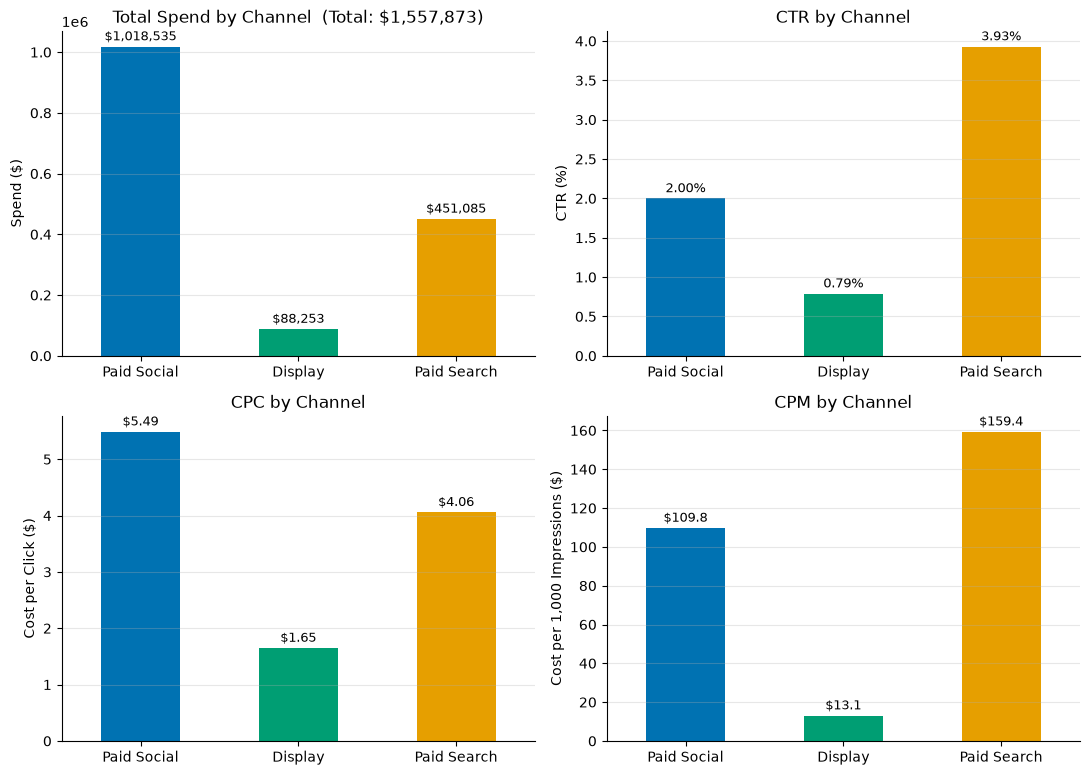

In [43]:
ads_order = ['Paid Social', 'Display', 'Paid Search']
ads_summary = paid_ads.groupby('channel').agg(
    spend=('cost', 'sum'),
    impressions=('impressions', 'sum'),
    clicks=('clicks', 'sum'),
).reindex(ads_order)
ads_summary['ctr'] = (ads_summary.clicks / ads_summary.impressions * 100).round(2)
ads_summary['cpc'] = (ads_summary.spend / ads_summary.clicks).round(2)
ads_summary['cpm'] = (ads_summary.spend / ads_summary.impressions * 1000).round(2)

colors = [channel_colors[c] for c in ads_order]
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

panels = [
    (ads_summary.spend, f'Total Spend by Channel  (Total: ${ads_summary.spend.sum():,.0f})', 'Spend ($)', '${:,.0f}'),
    (ads_summary.ctr, 'CTR by Channel', 'CTR (%)', '{:.2f}%'),
    (ads_summary.cpc, 'CPC by Channel', 'Cost per Click ($)', '${:,.2f}'),
    (ads_summary.cpm, 'CPM by Channel', 'Cost per 1,000 Impressions ($)', '${:,.1f}'),
]

for ax, (data, title, ylabel, fmt) in zip(axes.flat, panels):
    data.plot(kind='bar', ax=ax, color=colors)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3)
    for i, v in enumerate(data):
        ax.text(i, v + (data.max() * 0.02), fmt.format(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

**Conclusion:** `Paid Social` absorbs 65% of the $1.56M total spend ($1.02M) but has the *worst* CPC ($5.49) and mid-pack CPM. `Display` is the cheapest channel by far on both CPC ($1.65) and CPM ($13.08), despite having the lowest CTR (0.79%) of the three — low click-through doesn't mean poor efficiency once cost is factored in. `Paid Search` has the best CTR (3.93%) but the highest CPM ($159.37), the classic expensive-but-relevant-intent channel. Combined with the conversion-rate chart above (Display's 11.2% is the best), this is a real signal worth carrying into the CAC metric: **Display looks weak on the surface (CTR) but is quietly the most efficient channel end-to-end.**

**Important caveat — attribution vs. incrementality.** Our attribution here is **last-touch**: a lead is credited entirely to the one `campaign_id` on its CRM record, with no visibility into any earlier touchpoints. This matters specifically for `Display`, because Display campaigns are conventionally run as **retargeting** — shown to people who already visited the site or engaged elsewhere, i.e. people who were often already likely to convert regardless. Last-touch attribution systematically flatters retargeting-style channels: it credits Display with conversions that Paid Social or Paid Search may have actually originated further upstream.

So while Display shows the best conversion rate and lowest CPC/CPM here — consistent with it also having the cheapest CAC, already computed in Section 5 ($4,645) — this is a **correlational, attributed efficiency**, not a proven causal/incremental one. The true incremental lift of Display (what conversions it *added* versus would have happened anyway) is very plausibly lower than these numbers suggest.

**We can't resolve this with the data we have** — there's no click-path/session history or geographic holdout design available. In a real setting, this would normally be addressed with:
1. **Multi-touch attribution** (e.g. a Shapley-value model) over the full click-path history per user, to fairly split credit across every touchpoint a lead had before converting, not just the last one.
2. **Geo-lift / incrementality testing** — holding out specific regions from a channel's spend and comparing conversion lift vs. exposed regions, to causally isolate that channel's true incremental value.

We flag this rather than silently present Display's efficiency numbers as the full picture.

**Why this is a near-certain overestimate, not just an unmeasured risk**: Display's typical real-world mechanic is retargeting — it fires *after* a person has already engaged with the brand somewhere else (visited the site, clicked a Paid Social/Search ad, etc.). That means the retargeted person was frequently already on a path to convert before the Display ad ever appeared; the ad inserts itself late in a journey it didn't originate. Under last-touch attribution, that gets recorded as a Display-driven conversion regardless. This isn't a symmetric "could go either way" uncertainty — the structural direction of the bias is toward **overstating** Display's true incremental contribution specifically, more so than the other channels. This is exactly why retargeting-heavy channels are the standard first candidate for incrementality/geo-lift testing in real marketing orgs, and why we don't recommend shifting budget toward Display on this data alone.

#### Additional Paid Ads views

Three more cuts before moving to CAC: whether spend allocation shifted over the year, whether channel-level averages are representative of individual campaigns or hide an outlier, and how volatile daily spend is per channel.

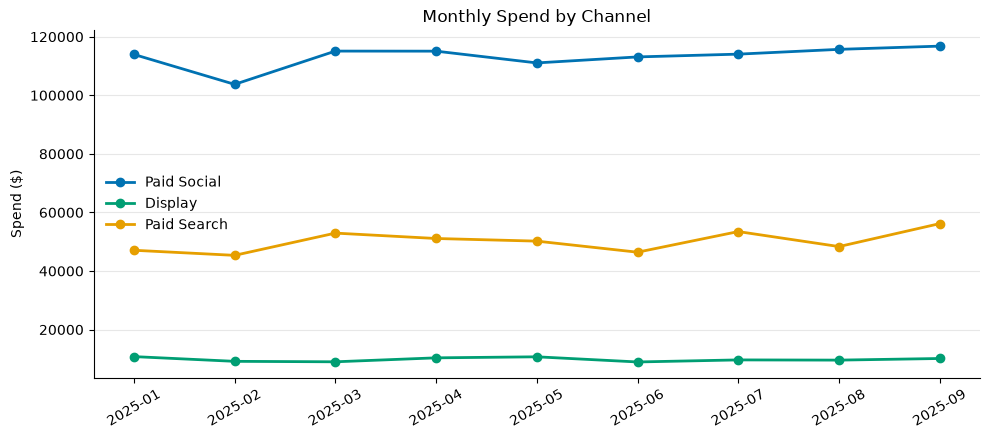

In [44]:
monthly = paid_ads.copy()
monthly['month'] = monthly.date.dt.to_period('M')
spend_trend = monthly.groupby(['month', 'channel']).cost.sum().unstack().reindex(columns=ads_order)

fig, ax = plt.subplots(figsize=(10, 4.5))
for ch in ads_order:
    ax.plot(spend_trend.index.astype(str), spend_trend[ch], marker='o', linewidth=2, color=channel_colors[ch], label=ch)
ax.set_title('Monthly Spend by Channel')
ax.set_ylabel('Spend ($)')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
ax.legend(frameon=False)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Conclusion:** spend by channel is remarkably flat across all 9 months — no ramp-up, no seasonality, no reallocation between channels over the year. Practically, this means a single full-period CAC number is representative and won't be distorted by within-year budget shifts (there weren't any) — we don't need to compute CAC month-by-month to get a trustworthy read.

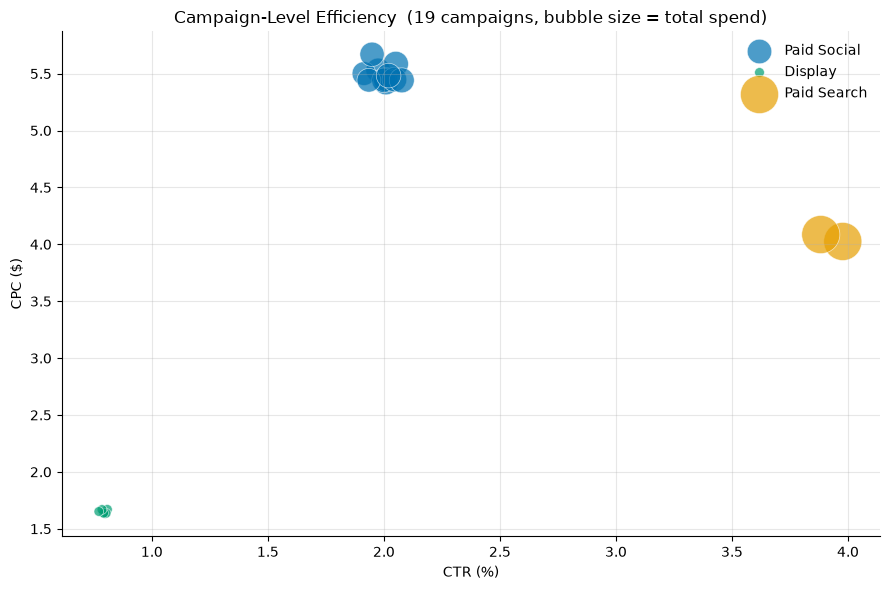

In [45]:
campaign_summary = paid_ads.groupby(['campaign_id', 'campaign_name', 'channel']).agg(
    spend=('cost', 'sum'), impressions=('impressions', 'sum'), clicks=('clicks', 'sum')).reset_index()
campaign_summary['ctr'] = campaign_summary.clicks / campaign_summary.impressions * 100
campaign_summary['cpc'] = campaign_summary.spend / campaign_summary.clicks

fig, ax = plt.subplots(figsize=(9, 6))
for ch in ads_order:
    sub = campaign_summary[campaign_summary.channel == ch]
    ax.scatter(sub.ctr, sub.cpc, s=sub.spend / 300, color=channel_colors[ch], alpha=0.7,
               edgecolor='white', linewidth=0.5, label=ch)
ax.set_xlabel('CTR (%)')
ax.set_ylabel('CPC ($)')
ax.set_title('Campaign-Level Efficiency  (19 campaigns, bubble size = total spend)')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(alpha=0.3)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

**Conclusion:** campaigns cluster tightly by channel — all 6 Display campaigns sit within CPC $1.63–$1.67, all 9 Paid Social campaigns within $5.42–$5.67, both Paid Search campaigns within $4.03–$4.09. No single outlier campaign is inflating or deflating any channel's average — the channel-level numbers we computed earlier are genuinely representative of every campaign within them, not skewed by one unusually good or bad performer.

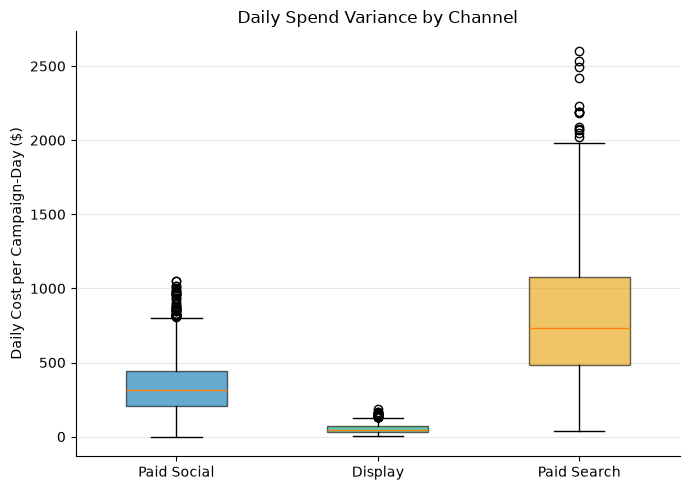

In [46]:
fig, ax = plt.subplots(figsize=(7, 5))
data_by_channel = [paid_ads[paid_ads.channel == ch].cost for ch in ads_order]
bp = ax.boxplot(data_by_channel, tick_labels=ads_order, patch_artist=True, widths=0.5)
for patch, ch in zip(bp['boxes'], ads_order):
    patch.set_facecolor(channel_colors[ch])
    patch.set_alpha(0.6)
ax.set_ylabel('Daily Cost per Campaign-Day ($)')
ax.set_title('Daily Spend Variance by Channel')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Conclusion:** `Paid Search` is by far the spikiest channel day-to-day (mean $826, std $459, up to $2,604 on peak days) — consistent with search bidding dynamics (auction-based CPCs fluctuate with competition). `Display` is the most stable (mean $54, std $30). `Paid Social` sits in between. This matters operationally more than for our metrics directly: Paid Search budgets need more active day-to-day monitoring, while Display spend is predictable "set and forget."

### Conversion (CRM)

**Channel attribution for CRM**: `campaign_id` links each lead back to `paid_ads.channel`. Leads with no `campaign_id` (Section 3 of Verifying Assumptions) are bucketed as `"Organic/Unattributed"`. For conversion rate, each **company counts as one conversion** — attributed to the channel of its *earliest* winning lead — consistent with the `company_name` rollup we already established for the cohort analysis, so a company that converted more than once isn't double-counted.

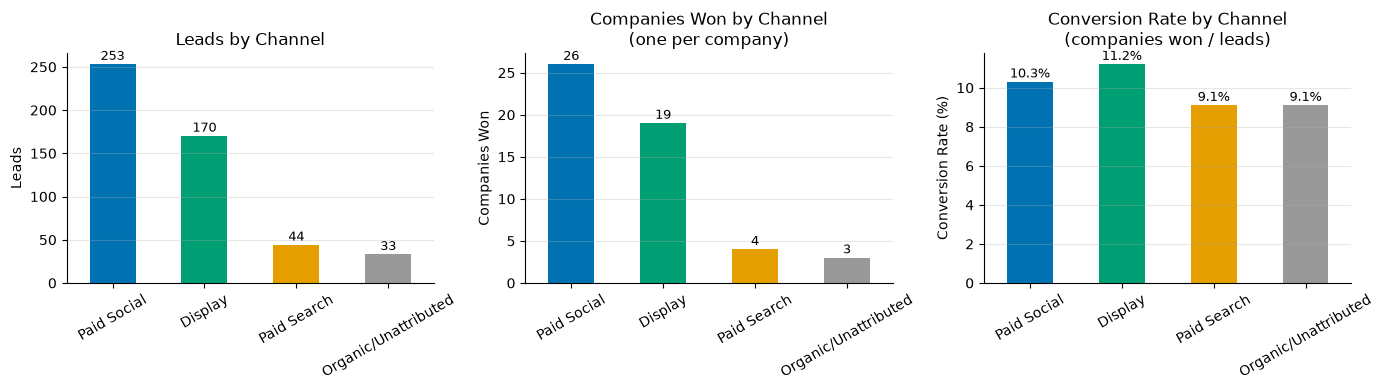

In [47]:
# channel_colors, channel_order, and crm_pipeline['channel'] were already set up in Section 4 (cell 76) - reused as-is here
leads_by_channel = crm_pipeline.channel.value_counts().reindex(channel_order)

won_leads = crm_pipeline[crm_pipeline.lifecycle_stage == 'Closed Won'].sort_values('close_date')
earliest_won = won_leads.groupby('company_name').first()  # one row per company = one conversion
won_by_channel = earliest_won.channel.value_counts().reindex(channel_order).fillna(0)

conv_rate = (won_by_channel / leads_by_channel * 100).round(1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = [channel_colors[c] for c in channel_order]

for ax, data, title, ylabel, fmt in zip(
    axes,
    [leads_by_channel, won_by_channel, conv_rate],
    ['Leads by Channel', 'Companies Won by Channel\n(one per company)', 'Conversion Rate by Channel\n(companies won / leads)'],
    ['Leads', 'Companies Won', 'Conversion Rate (%)'],
    ['{:.0f}', '{:.0f}', '{:.1f}%'],
):
    data.plot(kind='bar', ax=ax, color=colors)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3)
    for i, v in enumerate(data):
        ax.text(i, v + (data.max() * 0.02), fmt.format(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

**Conclusion:** `Paid Social` brings in the most leads (253) and the most won companies in absolute terms (26), but its conversion rate (10.3%) is actually middling. `Display` has fewer leads (170) but the **best conversion rate of any channel (11.2%)**. Notably, `Organic/Unattributed` — leads with no ad spend behind them at all — converts at 9.1%, roughly in line with `Paid Search`, which is a useful data point for the CAC conversation next: some real volume of wins isn't coming from paid channels at all.

In [48]:
# company-grain win rate by entry channel (resolved deals only) -- referenced later in
# the dormant-reactivation recommendation (Section 8), computed here so it's traceable
resolved_companies = company_df[company_df.outcome.isin(['Closed Won', 'Closed Lost'])]
win_rate_by_entry_channel = (resolved_companies.outcome == 'Closed Won').groupby(resolved_companies.entry_channel).mean().reindex(channel_order).dropna()
print('Company-grain win rate by entry channel (Won / (Won+Lost), resolved companies only):')
print((win_rate_by_entry_channel * 100).round(1))

Company-grain win rate by entry channel (Won / (Won+Lost), resolved companies only):
entry_channel
Paid Social             51.9
Display                 64.0
Paid Search             55.6
Organic/Unattributed    50.0
Name: outcome, dtype: float64


**Conclusion:** at company grain, `Display`-originated companies win at **64.0%** once resolved, versus 55.6% (Paid Search), 51.9% (Paid Social), and 50.0% (Organic/Unattributed) — a real gap, though on a small base (resolved companies per channel range from ~18-40). This is the channel win-rate context the dormant-reactivation recommendation (Section 8) uses alongside recency to prioritize outreach, in place of the propensity model's failed score.

**Metric 2 (43.3% win rate) was computed in Section 5.** Here we go a level deeper on the *other* side of that number — the 26 companies that haven't resolved yet. Are they genuinely still active deals, or effectively dead and just sitting open? The next few views build up to a statistically rigorous answer (Kaplan-Meier survival analysis), rather than eyeballing it.

#### First-Touch vs. Eventual Lead Qualification

A follow-up on the trial-adoption finding earlier (95.8% of companies eventually trial): the more interesting question is how many companies qualify to MQL on their **first** lead vs. only get there after a **later** re-engagement. These support different claims — first-touch quality (how well-targeted is our top-of-funnel) vs. nurture effectiveness (does persistence pay off) — so worth separating rather than reporting one blended number.

In [49]:
first_leads = crm_pipeline.sort_values('created_at').groupby('company_name').first()
n_companies_ft = len(first_leads)

first_touch_mql = (first_leads.stage_rank >= 1).sum()
ever_reached_mql = (company_df.peak_rank >= 1).sum()

print(f'Companies whose FIRST lead ever reached MQL+: {first_touch_mql}/{n_companies_ft} ({first_touch_mql/n_companies_ft:.1%})')
print(f'Companies that EVER reach MQL+ (any lead, company grain): {ever_reached_mql}/{len(company_df)} ({ever_reached_mql/len(company_df):.1%})')
print(f'Gap — companies that only qualified via a LATER, re-engaged lead: {ever_reached_mql - first_touch_mql}')

Companies whose FIRST lead ever reached MQL+: 90/120 (75.0%)
Companies that EVER reach MQL+ (any lead, company grain): 117/120 (97.5%)
Gap — companies that only qualified via a LATER, re-engaged lead: 27


**Conclusion:** **75% of companies qualify to MQL on their very first lead** — a solid, honest read on top-of-funnel targeting quality, since it isolates first-contact fit rather than crediting repeat outreach. The company-grain "ever reaches MQL" figure is higher (97.5%), but ~27 of those companies only got there via a **later** lead, months after the first attempt stalled — that's a nurture/re-engagement success story, not a lead-quality one. Read together: leads arriving are reasonably well-targeted at first touch, *and* persistence recovers most of the remainder that don't qualify immediately — two distinct, worth-stating strengths rather than one inflated stat.

#### Lead Volume Over Time, and Leads per Company

Two more views: how lead volume trended month to month, and the distribution of leads per company (a visual of the identity-resolution finding).

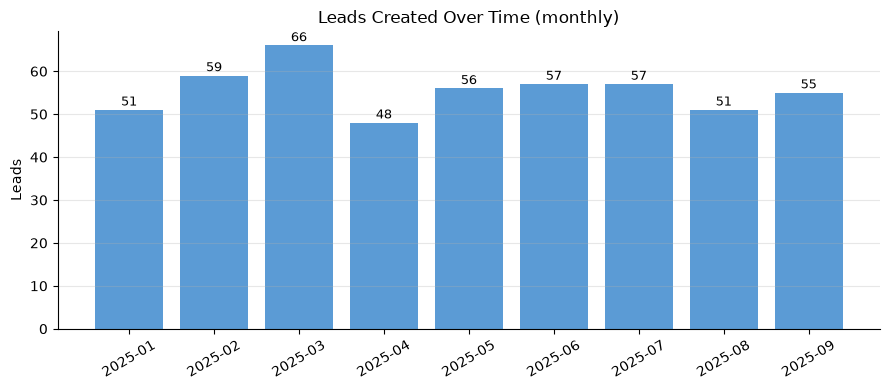

In [50]:
leads_monthly = crm_pipeline.copy()
leads_monthly['month'] = leads_monthly.created_at.dt.to_period('M')
monthly_counts = leads_monthly.groupby('month').size()

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(monthly_counts.index.astype(str), monthly_counts.values, color='#5B9BD5')
ax.set_title('Leads Created Over Time (monthly)')
ax.set_ylabel('Leads')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=30)
for i, v in enumerate(monthly_counts.values):
    ax.text(i, v + 1, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

**Conclusion:** lead volume is fairly flat month to month (48–66/month, no clear trend or seasonality) — consistent with the flat ad-spend trend we already found. Lead generation wasn't ramping or declining over the year; it moved in a narrow, stable band.

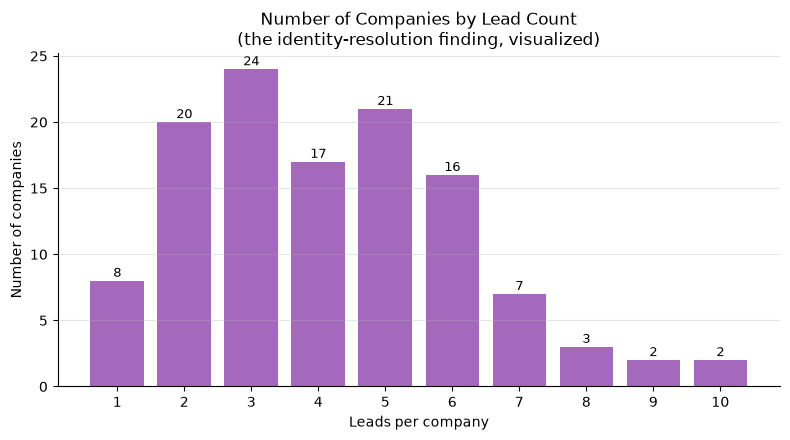

In [51]:
leads_per_company = crm_pipeline.company_name.value_counts().value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(leads_per_company.index.astype(str), leads_per_company.values, color='#8E44AD', alpha=0.8)
ax.set_title('Number of Companies by Lead Count\n(the identity-resolution finding, visualized)')
ax.set_xlabel('Leads per company')
ax.set_ylabel('Number of companies')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(leads_per_company.values):
    ax.text(i, v + 0.3, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

**Conclusion:** only 8 of 120 companies (7%) show up with exactly 1 lead — the overwhelming majority have 2–6, with a long tail up to 10 (Vehement Corporation). This is the same identity-resolution finding from Verifying Assumptions #1, now visualized directly — most companies are represented by *multiple* lead records, which is exactly why using `company_name` as the account key (rather than `company_id`) materially changes every rate we compute.

#### Sales Cycle Length, and Judging the "Stalled" Leads

CRM only gives us 3 timestamps per lead — `created_at`, `opportunity_created_at`, `close_date` — not a full per-stage transition log. So we can measure two real segments (**Lead → Opportunity** and **Opportunity → Close**), not the exact `Lead → MQL → SQL` handoffs. That's still enough to answer the real question: are the currently "stalled" leads (still `Lead`/`MQL`/`SQL`) just early in a normal cycle, or already well past how long a deal normally takes?

**Data quality flag before we trust this:** 6 of 162 opportunities have `close_date` *before* `opportunity_created_at` (by 4–8 days) — a deal can't close before its opportunity existed. This is a small share (3.7%) and we leave them in (excluding them wouldn't meaningfully change the picture), but it's worth naming rather than silently averaging over.

In [52]:
# deep dive on the 6 rows where close_date < opportunity_created_at
crm_pipeline['opp_to_close_days_raw'] = (crm_pipeline.close_date - crm_pipeline.opportunity_created_at).dt.days
bad_rows = crm_pipeline[crm_pipeline.opp_to_close_days_raw < 0]

print(f'{len(bad_rows)} of {crm_pipeline.close_status.notna().sum()} resolved leads affected ({len(bad_rows)/crm_pipeline.close_status.notna().sum():.1%})')
print()
print(bad_rows[['lead_id', 'company_name', 'created_at', 'opportunity_created_at', 'close_date', 'close_status']].to_string(index=False))
print()
print('gap size (days):', sorted(bad_rows.opp_to_close_days_raw.tolist()))
print('created_at -> close_date still valid (positive) for all 6?',
      ((bad_rows.close_date - bad_rows.created_at).dt.days > 0).all())

6 of 162 resolved leads affected (3.7%)

  lead_id         company_name created_at opportunity_created_at close_date close_status
LEAD_0037        Wayne Systems 2025-02-18             2025-03-26 2025-03-20         Lost
LEAD_0116    Globex Industries 2025-08-30             2025-10-02 2025-09-28          Won
LEAD_0121 Vehement Corporation 2025-09-17             2025-10-22 2025-10-16         Lost
LEAD_0139   Umbrella Solutions 2025-01-04             2025-02-10 2025-02-05         Lost
LEAD_0389        Vandelay Labs 2025-07-16             2025-08-20 2025-08-12          Won
LEAD_0413   Soylent Industries 2025-03-26             2025-04-26 2025-04-20         Lost

gap size (days): [-8.0, -6.0, -6.0, -6.0, -5.0, -4.0]
created_at -> close_date still valid (positive) for all 6? True


**Conclusion:** the gap sizes are all small (4–8 days), the affected leads span both `Won`/`Lost` outcomes and different companies with no shared pattern, and critically `created_at → close_date` (the overall span) is still positive and valid for all 6 — only `opportunity_created_at` specifically lands after `close_date`. This reads as a synthetic-data generation edge case (likely `opportunity_created_at` was drawn independently rather than constrained to fall before `close_date`), not a systemic issue. **Treatment:** exclude these 6 from `lead_to_opp_days` and `opp_to_close_days` (where the bad field is directly used), but keep them in `total_cycle_days` (`created_at → close_date`, which is unaffected and valid).

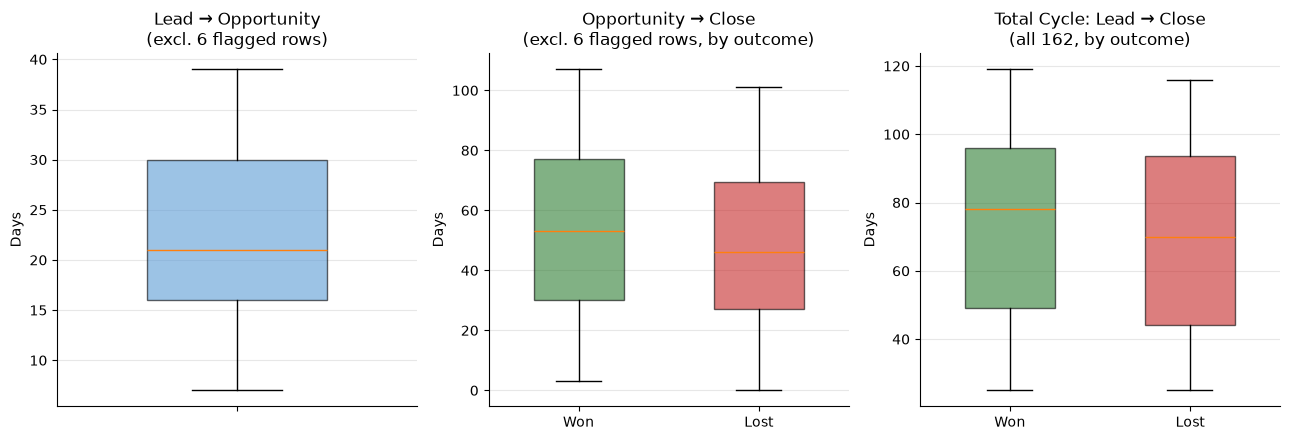

In [53]:
crm_pipeline['lead_to_opp_days'] = (crm_pipeline.opportunity_created_at - crm_pipeline.created_at).dt.days
crm_pipeline['opp_to_close_days'] = (crm_pipeline.close_date - crm_pipeline.opportunity_created_at).dt.days
crm_pipeline['total_cycle_days'] = (crm_pipeline.close_date - crm_pipeline.created_at).dt.days

resolved = crm_pipeline[crm_pipeline.close_status.notna()]
resolved_clean = resolved[resolved.opp_to_close_days >= 0]  # excludes the 6 flagged rows, only for the affected segments
outcome_colors = {'Won': '#2E7D32', 'Lost': '#C62828'}

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
segments = [('lead_to_opp_days', 'Lead → Opportunity\n(excl. 6 flagged rows)', None, resolved_clean),
            ('opp_to_close_days', 'Opportunity → Close\n(excl. 6 flagged rows, by outcome)', 'close_status', resolved_clean),
            ('total_cycle_days', 'Total Cycle: Lead → Close\n(all 162, by outcome)', 'close_status', resolved)]

for ax, (col, title, split, data_source) in zip(axes, segments):
    if split:
        data = [data_source[data_source.close_status == s][col] for s in ['Won', 'Lost']]
        bp = ax.boxplot(data, tick_labels=['Won', 'Lost'], patch_artist=True, widths=0.5)
        for patch, s in zip(bp['boxes'], ['Won', 'Lost']):
            patch.set_facecolor(outcome_colors[s])
            patch.set_alpha(0.6)
    else:
        ax.boxplot(data_source[col], tick_labels=[''], patch_artist=True, widths=0.5,
                   boxprops=dict(facecolor='#5B9BD5', alpha=0.6))
    ax.set_title(title)
    ax.set_ylabel('Days')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Conclusion:** median Lead→Opportunity is 21 days; Opportunity→Close is similar for both outcomes (Won: median 52 days, Lost: median 43 days) — Won deals take slightly *longer* to close than Lost ones, which makes sense (a "no" can come quickly, a "yes" often needs more back-and-forth). Total cycle (Lead→Close) is ~70 days for Lost, ~78 days for Won, both averaging roughly 70–80 days end to end.

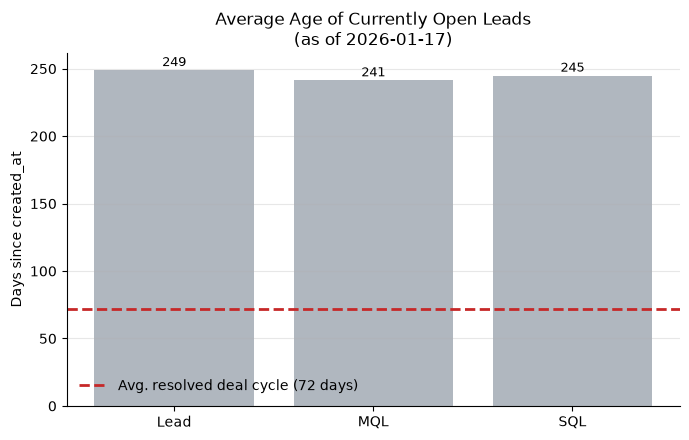

In [54]:
# use the dataset's true latest known date (not just CRM's own created_at.max()) as "today"
as_of_date = crm_pipeline.close_date.max()
avg_resolved_cycle = resolved.total_cycle_days.mean()

open_leads = crm_pipeline[crm_pipeline.lifecycle_stage.isin(['Lead', 'MQL', 'SQL'])].copy()
open_leads['age_days'] = (as_of_date - open_leads.created_at).dt.days
age_by_stage = open_leads.groupby('lifecycle_stage').age_days.mean().reindex(['Lead', 'MQL', 'SQL'])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(age_by_stage.index, age_by_stage.values, color='#B0B7BF')
ax.axhline(avg_resolved_cycle, color='#C62828', linestyle='--', linewidth=2,
           label=f'Avg. resolved deal cycle ({avg_resolved_cycle:.0f} days)')
ax.set_title(f'Average Age of Currently Open Leads\n(as of {as_of_date.date()})')
ax.set_ylabel('Days since created_at')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
ax.legend(frameon=False)
for i, v in enumerate(age_by_stage.values):
    ax.text(i, v + 3, f'{v:.0f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

**Conclusion — this is the actionable one.** Currently "open" leads (still `Lead`/`MQL`/`SQL`) are on average **~240–250 days old**, roughly **3x longer** than the ~72-day average cycle time of deals that actually resolve. These aren't leads that are "still early in a normal cycle" — by the time a typical deal would have already closed one way or another, these are still sitting open. This strongly suggests most of the 238 currently-open leads are effectively dormant/stalled rather than genuinely in-progress, and is a concrete recommendation for the deck: **the sales/CRM process needs an explicit "stale lead" cutoff** (e.g. auto-disqualify or flag for re-engagement past ~90–120 days with no stage movement), since right now these leads sit indefinitely with no resolution. We validate this rigorously — with a proper survival-analysis model rather than an eyeballed mean comparison — in **Advanced Analysis** below.

### Retention (Product Usage + Cohort Analysis)

#### Product Usage Charts

Four views, sticking to the trustworthy fields (`event_type`, `event_time`, `company_id`, `user_id`) — `plan_tier`/`seats_used` are excluded per the Caveats section (they're per-event noise, not real account state).

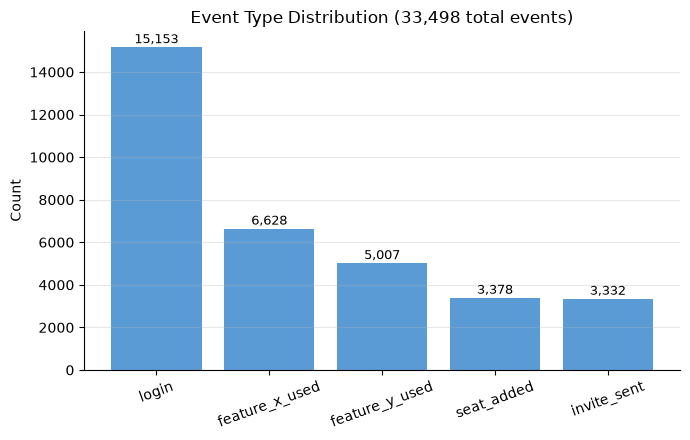

In [55]:
event_type_counts = product_usage_events.event_type.value_counts()

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(event_type_counts.index, event_type_counts.values, color='#5B9BD5')
ax.set_title('Event Type Distribution (33,498 total events)')
ax.set_ylabel('Count')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=20)
for i, v in enumerate(event_type_counts.values):
    ax.text(i, v + 200, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

**Conclusion:** `login` dominates at 15,153 (45%), followed by the two feature-usage events (`feature_x_used`: 6,628, `feature_y_used`: 5,007), then the two expansion signals `seat_added` (3,378) and `invite_sent` (3,332) at roughly equal, smaller volumes — consistent with logins being a baseline activity and the others representing deliberate, less frequent actions.

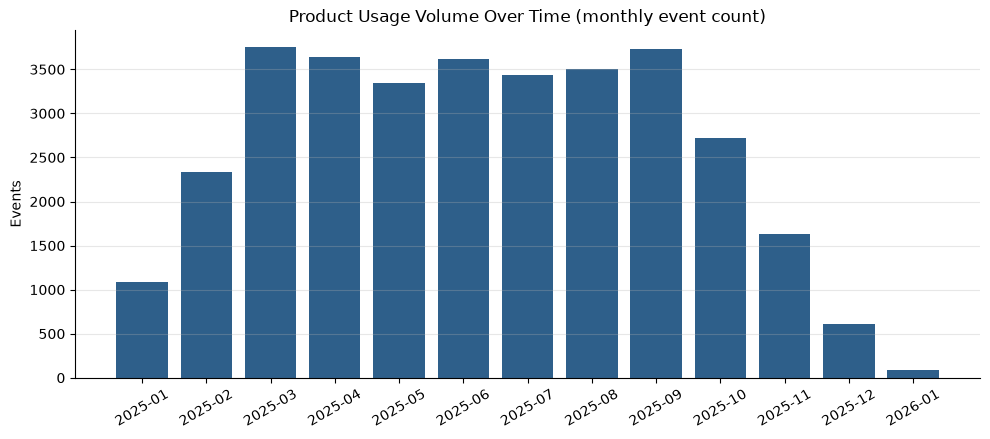

In [56]:
usage_monthly = product_usage_events.copy()
usage_monthly['month'] = usage_monthly.event_time.dt.to_period('M')
monthly_volume = usage_monthly.groupby('month').size()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(monthly_volume.index.astype(str), monthly_volume.values, color='#2E5F8A')
ax.set_title('Product Usage Volume Over Time (monthly event count)')
ax.set_ylabel('Events')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Conclusion:** volume ramps up Jan–Mar 2025 (new trials starting), plateaus at ~3,400–3,700 events/month through September, then tapers off Oct–Jan. This taper isn't a red flag — it's expected given what we already know: no new trials start after 2025-10-08 (Verifying Assumptions), so from October onward, usage volume can only come from Closed Won accounts still active, a shrinking and eventually-stable subset, plus the dataset itself cuts off mid-January 2026 (hence the sharp final-month drop to 84 events — a partial month, not a decline).

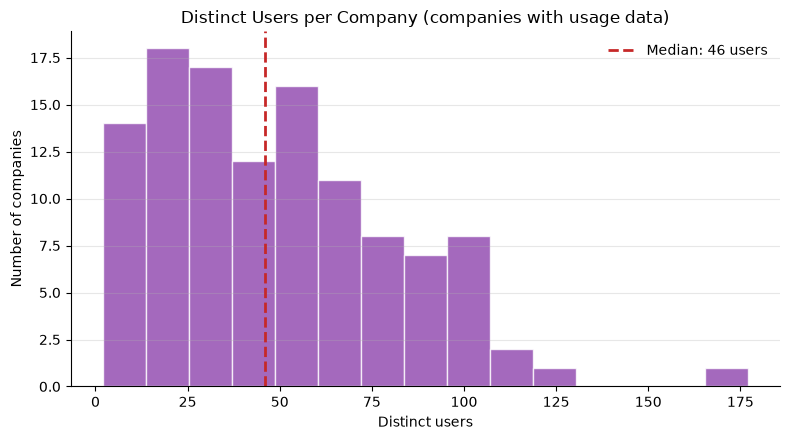

In [57]:
users_per_company = company_df[company_df.total_usage_events > 0].set_index('company_name').distinct_users

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(users_per_company, bins=15, color='#8E44AD', alpha=0.8, edgecolor='white')
ax.axvline(users_per_company.median(), color='#C62828', linestyle='--', linewidth=2,
           label=f'Median: {users_per_company.median():.0f} users')
ax.set_title('Distinct Users per Company (companies with usage data)')
ax.set_xlabel('Distinct users')
ax.set_ylabel('Number of companies')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

**Conclusion:** using the correctly-resolved `company_df` (not raw `company_id`), there are **115 companies with usage data**, not 311 — the earlier version of this chart was accidentally counting lead-grain IDs again, the exact bug we'd already fixed elsewhere. Distinct users per company: median 46, range 2–177, wider spread than before since we're now correctly pooling all of a company's usage-bearing leads together rather than treating each as a separate account.

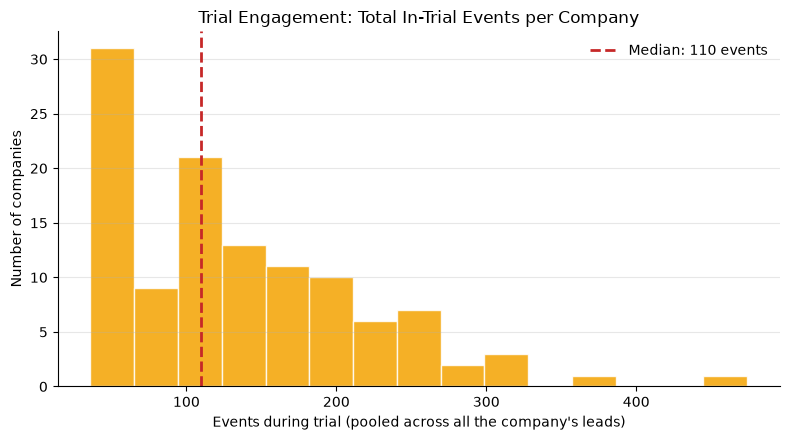

In [58]:
trial_engagement = company_df[company_df.total_usage_events > 0].set_index('company_name').trial_engagement_events

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(trial_engagement, bins=15, color='#F4A300', alpha=0.85, edgecolor='white')
ax.axvline(trial_engagement.median(), color='#C62828', linestyle='--', linewidth=2,
           label=f'Median: {trial_engagement.median():.0f} events')
ax.set_title('Trial Engagement: Total In-Trial Events per Company')
ax.set_xlabel("Events during trial (pooled across all the company's leads)")
ax.set_ylabel('Number of companies')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

**Conclusion:** median 110 in-trial events per company (range 36–474), computed correctly at company grain via `company_df` (pooling all of a company's leads' trial windows, not leaking post-close usage). Wider spread than the earlier lead-grain version, since some companies pooled multiple trial-bearing leads into one total.

#### Two More: Distinct Companies Over Time, and by Eventual Outcome

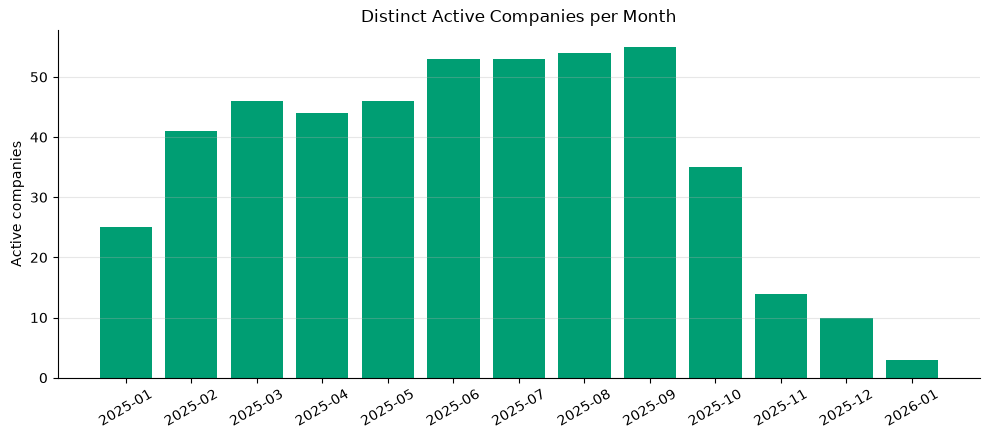

In [59]:
id_to_name_map = crm_pipeline[['company_id', 'company_name']].drop_duplicates()
usage_named_monthly = product_usage_events.merge(id_to_name_map, on='company_id')
usage_named_monthly['month'] = usage_named_monthly.event_time.dt.to_period('M')
active_monthly_co = usage_named_monthly.groupby('month').company_name.nunique()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(active_monthly_co.index.astype(str), active_monthly_co.values, color='#009E73')
ax.set_title('Distinct Active Companies per Month')
ax.set_ylabel('Active companies')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Conclusion:** correctly deduped to company grain, active companies peak at 53–55/month (Jun–Sep 2025), not the 60–67 the buggy `company_id` version showed. Shape still matches the event-volume trend (ramp, plateau, taper) — same explanation as before (no new trials after Oct 2025, data cutoff mid-Jan 2026), just on the correct denominator now.

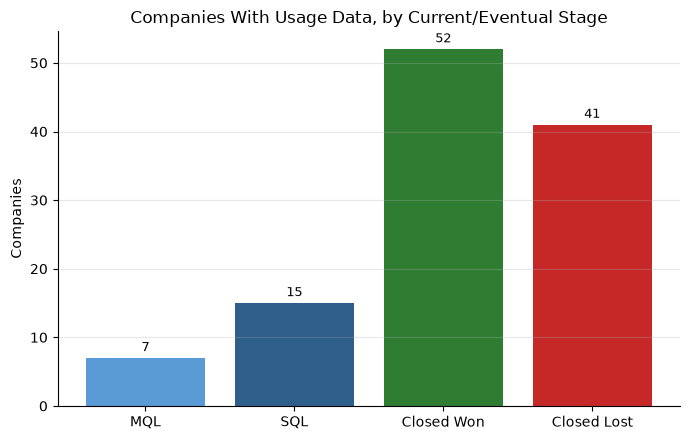

In [60]:
stage_of_usage_companies = company_df[company_df.total_usage_events > 0].set_index('company_name').outcome
stage_of_usage_companies_full = company_df[company_df.total_usage_events > 0].set_index('company_name').peak_rank.map(
    {1: 'MQL', 2: 'SQL', 3: 'Closed Lost', 4: 'Closed Won'})
stage_order = ['MQL', 'SQL', 'Closed Won', 'Closed Lost']
stage_colors_map = {'MQL': '#5B9BD5', 'SQL': '#2E5F8A', 'Closed Won': '#2E7D32', 'Closed Lost': '#C62828'}
stage_counts = stage_of_usage_companies_full.value_counts().reindex(stage_order)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(stage_counts.index, stage_counts.values, color=[stage_colors_map[s] for s in stage_order])
ax.set_title('Companies With Usage Data, by Current/Eventual Stage')
ax.set_ylabel('Companies')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(stage_counts.values):
    ax.text(i, v + 1, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

**Conclusion:** correctly deduped, 115 companies had usage: 52 Closed Won, 41 Closed Lost, 15 SQL, 7 MQL. The Closed Won count (52) exactly matches our funnel and cohort analysis — a good consistency check that `company_df` is built correctly. Unlike the earlier lead-grain version (which showed a suspiciously even split across all 4 stages), this one is dominated by resolved companies (93 of 115), which makes sense: usage/trial access naturally concentrates in the population that progressed far enough to trial, and most of those eventually resolve one way or another.

#### Exploring Retention: Cohort Analysis (Preview)

This is the full cohort table behind metric #5 (Section 5) — the retention/churn definition and headline number were already decided and computed there, using this exact data. Shown here in supporting depth: the complete quarterly retention table and the right-censoring caveat that shaped that decision. Cohorts are bucketed by **quarter** of `close_date` (chosen over monthly — too few Closed Won accounts for monthly cohorts to be readable).

**Correction applied:** the first version of this analysis grouped by `company_id`, but we already established `company_id` is lead-grain, not account-grain — and it turns out this actually mattered here: **17 `company_name`s have 2–3 separate Closed Won `company_id`s** (e.g. the same real company converting more than once under different lead records). Grouping by `company_id` would have double/triple-counted those as separate customers. Fixed below by rolling up to `company_name` first — the true account count is **52 distinct Closed Won companies**, not 71.

In [61]:
won = crm_pipeline[crm_pipeline.lifecycle_stage == 'Closed Won'].copy()

# roll up to company_name: a company's "customer since" date is the EARLIEST close_date
# across any of its (possibly multiple) Closed Won leads
company_won = won.groupby('company_name').agg(
    close_date=('close_date', 'min'),
    company_ids=('company_id', list),
).reset_index()
company_won['close_quarter'] = company_won.close_date.dt.to_period('Q')

cohort_sizes = company_won.groupby('close_quarter').company_name.nunique()
print('Distinct Closed Won companies:', len(company_won), '(vs.', len(won), 'Closed Won leads)')
print()
print('Cohort size (companies) by close quarter:')
print(cohort_sizes)

Distinct Closed Won companies: 52 (vs. 71 Closed Won leads)

Cohort size (companies) by close quarter:
close_quarter
2025Q1     6
2025Q2    22
2025Q3    15
2025Q4     8
2026Q1     1
Freq: Q-DEC, Name: company_name, dtype: int64


In [62]:
# map every company_id belonging to a Closed Won company (there can be several) to that company's cohort
id_to_company = company_won.explode('company_ids').rename(columns={'company_ids': 'company_id'})[
    ['company_id', 'company_name', 'close_quarter']]

usage_won = product_usage_events.merge(id_to_company, on='company_id')  # inner join: only Closed Won companies
usage_won['event_quarter'] = usage_won.event_time.dt.to_period('Q')
# period_number: how many quarters after close this activity happened (-1 = trial activity, pre-close)
usage_won['period_number'] = usage_won.event_quarter.astype('int64') - usage_won.close_quarter.astype('int64')

active = usage_won.groupby(['close_quarter', 'period_number']).company_name.nunique().unstack()
retention = active.div(cohort_sizes, axis=0).round(2)
print('Retention table — share of each cohort active in period N (0 = close quarter):')
retention

Retention table — share of each cohort active in period N (0 = close quarter):


period_number,-1,0,1,2,3,4
close_quarter,,,,,,
2025Q1,NaN,1.00,0.33,0.33,0.33,0.17
2025Q2,0.77,0.77,0.32,0.18,NaN,NaN
2025Q3,0.60,0.93,0.53,NaN,NaN,NaN
2025Q4,0.88,0.88,0.25,NaN,NaN,NaN
2026Q1,1.00,NaN,NaN,NaN,NaN,NaN


**Important caveat — right-censoring:** our usage data only runs through mid-January 2026. For the 2025Q4 cohort, "period 1" (Q1 2026) is only observed for ~2 weeks — that 25% understates true retention, it's not a real churn signal yet. The 2026Q1 cohort (n=1) has essentially no post-close observation window and shouldn't be read as data.

**What's actually trustworthy** (fully-observed transitions, company_name grain): 2025Q1→Q2 (33%), Q2→Q3 (32%), Q3→Q4 (53%). Three data points, still a thin base, but real signal — and notably the 2025Q1 cohort holds fairly flat after its first-quarter drop (33% → 33% → 33% → 17%), suggesting whoever survives the first quarter tends to stick around, with a further step down much later.

**Decision made (Section 5):** churn is defined via period-1 (first full quarter post-close) retention, averaged across the three cleanly-observed 2025 cohorts (Q1/Q2/Q3) — giving ~39.5% retention / ~60.5% implied quarterly churn. The 2025Q4 and 2026Q1 cohorts are excluded from that headline number specifically because of the right-censoring shown above, not shown with a different visual treatment — full exclusion was the simpler, more defensible call given how little of either cohort's "period 1" is actually observed.

**Minor additional caveat**: beyond right-censoring, Section 3's Verifying Assumptions #6 flags a small data quality issue in the underlying usage events (98% of companies show some post-trial usage, including non-converted ones) — but at a magnitude ~50-65x smaller than Closed-Won's own post-close usage, so it reads as trailing noise rather than a material distortion of the decay shape above. Still worth naming: read this cohort table directionally, not as precise churn measurement.

### Advanced Analysis (Optional)

Everything below goes beyond what's strictly needed to answer the assignment's core questions — kept in to demonstrate additional statistical/ML depth, not because the core business story requires it. The underlying business conclusion in each case was already reached with the basic tools above: Conversion's simple mean-age comparison already showed stalled leads need a cutoff; what follows sharpens that into a precise, statistically defensible threshold (with a confidence interval) instead of a felt sense of "these seem old." One honesty note: Recommendation #1 in Section 8 does cite the exact 119-day figure derived here, but the underlying business call — deploy *some* stale-lead cutoff — doesn't hinge on this specific analysis existing, only on the informal finding above. If you're short on time, the core story (metrics, acquisition/conversion/retention findings, recommendations) stands on its own without this section.

#### Statistically Defining "Dormant": Kaplan-Meier Survival Analysis

The chart above eyeballs it with a mean comparison. Let's be rigorous instead. This is a textbook **survival analysis** problem: some leads have a known, observed "time to close" (an *event*), others are still open with an unknown eventual outcome — they're **right-censored**. A proper survival model (Kaplan-Meier) uses both, rather than just averaging the resolved ones.

**Grain matters here, and we got it wrong on the first pass.** Fitting this on all 500 raw leads treats every lead as an independent at-risk observation. But we already know many companies have multiple leads (the identity-resolution finding) — and critically, when two leads from the same company are both pursued, the company typically resolves through *one* of them while the other simply sits open forever, superseded, never formally closed. Counting that superseded lead as "censored, might still resolve" is wrong — its company's fate was already decided elsewhere. This inflated our censored pool to 338 leads when the real number of companies genuinely still undecided is only 26.

**Fix:** we refit at **company grain** — one observation per company, matching the funnel/Sankey logic already built. For each company: if it ever reached Closed Won/Lost, `event=1` and `duration` is that specific closing lead's own cycle time (`created_at` → `close_date`); if every one of its leads is still open, `event=0` (censored) and `duration` is time since its *most recent* lead's `created_at`. This gives 120 companies: 94 events, 26 censored — and removes the duplicate-lead distortion entirely (it's also no longer subject to the earlier independence caveat, since each company contributes exactly one observation now).

**The math.** The survival function S(t) = P(a company is still unresolved after t days). At every time point tᵢ where a close actually happens: nᵢ = number of companies still "at risk" just before tᵢ; dᵢ = number that closed exactly at tᵢ. **S(t) = ∏ (1 − dᵢ/nᵢ)**, over every event time tᵢ ≤ t. Censored companies still contribute to every nᵢ up until their own censoring point — they're not wasted, we just stop assuming an outcome for them beyond that point.

**Confidence interval.** Greenwood's formula: Var[S(t)] = S(t)² × Σ dᵢ/(nᵢ(nᵢ−dᵢ)). 95% CI = S(t) ± 1.96 × SE(t), using `surv_prob_se` from `statsmodels.duration.survfunc.SurvfuncRight`.

n companies: 120 | events: 94 | censored: 26


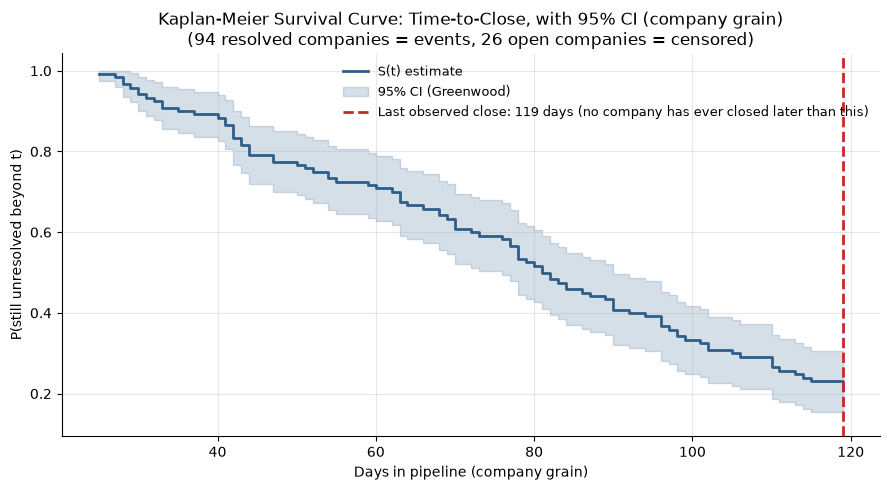

Last observed event (close) at: 119 days
S(119) = 0.211, SE = 0.038, 95% CI = [0.137, 0.285]
Companies currently open beyond this point: 21 of 26


In [63]:
from statsmodels.duration.survfunc import SurvfuncRight

def company_survival_row(g):
    peak = g.stage_rank.max()
    if peak >= 3:  # resolved: use the SPECIFIC lead that actually closed (Won takes priority if both exist)
        won = g[g.lifecycle_stage == 'Closed Won']
        lost = g[g.lifecycle_stage == 'Closed Lost']
        rep = won.sort_values('close_date').iloc[[0]] if len(won) else lost.sort_values('close_date').iloc[[0]]
        dur = (rep.close_date.iloc[0] - rep.created_at.iloc[0]).days
        return pd.Series({'duration': dur, 'event': 1})
    else:  # still open: use the MOST RECENT lead's created_at, consistent with the dormant/alive classification below
        most_recent = g.sort_values('created_at').iloc[[-1]]
        dur = (as_of_date - most_recent.created_at.iloc[0]).days
        return pd.Series({'duration': dur, 'event': 0})

company_survival = crm_pipeline.groupby('company_name').apply(company_survival_row, include_groups=False)
print('n companies:', len(company_survival), '| events:', company_survival.event.sum(),
      '| censored:', (company_survival.event == 0).sum())

sf = SurvfuncRight(company_survival.duration.values, company_survival.event.values)
lcb = np.clip(sf.surv_prob - 1.96 * sf.surv_prob_se, 0, 1)
ucb = np.clip(sf.surv_prob + 1.96 * sf.surv_prob_se, 0, 1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.step(sf.surv_times, sf.surv_prob, where='post', color='#2E5F8A', linewidth=2, label='S(t) estimate')
ax.fill_between(sf.surv_times, lcb, ucb, step='post', color='#2E5F8A', alpha=0.2, label='95% CI (Greenwood)')

last_event_time = company_survival[company_survival.event == 1].duration.max()
ax.axvline(last_event_time, color='#C62828', linestyle='--', linewidth=2,
           label=f'Last observed close: {last_event_time:.0f} days (no company has ever closed later than this)')
ax.set_xlabel('Days in pipeline (company grain)')
ax.set_ylabel('P(still unresolved beyond t)')
ax.set_title('Kaplan-Meier Survival Curve: Time-to-Close, with 95% CI (company grain)\n(94 resolved companies = events, 26 open companies = censored)')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(alpha=0.3)
ax.legend(frameon=False, loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

idx = np.searchsorted(sf.surv_times, last_event_time, side='right') - 1
print(f'Last observed event (close) at: {last_event_time:.0f} days')
print(f'S({last_event_time:.0f}) = {sf.surv_prob[idx]:.3f}, SE = {sf.surv_prob_se[idx]:.3f}, '
      f'95% CI = [{lcb[idx]:.3f}, {ucb[idx]:.3f}]')
print(f'Companies currently open beyond this point: {(company_survival[company_survival.event==0].duration > last_event_time).sum()} of {(company_survival.event==0).sum()}')

**Conclusion — this is the mathematically grounded threshold.** No company in this dataset — across 94 resolved companies — has ever taken longer than **119 days** (from its closing lead's own creation to its close) to resolve. At that point, S(119) ≈ 0.211 with a 95% CI of roughly [0.14, 0.29] — i.e. we're statistically confident that only about a fifth of companies remain unresolved that long, a real, estimated proportion now correctly based on 120 independent companies rather than 500 non-independent lead records. Beyond day 119, the curve is flat since only censored companies remain and zero further events have ever been observed. **We define "dormant" as: currently open, and already past 119 days since the company's most recent contact** — this now matches the enhanced funnel below exactly (21 of 26 open companies), since both use the same company-grain, most-recent-contact logic.

#### Enhanced Funnel: Splitting "Stalled" into Dormant vs. Still Active

We keep the original funnel above as-is. This is a second, more advanced view that applies the 119-day threshold to split each stalled bucket into **Dormant** (no historical precedent) vs. **Still Active** (within a normal window).

One choice worth being explicit about: for companies with multiple leads (our identity-resolution finding), do we measure age from their *earliest* contact, or their *most recent*? We use **most recent contact** — a company's most recent lead is the better signal of current engagement; an old first touch from over a year ago shouldn't count against a company that re-engaged more recently. (For reference: using earliest contact instead would classify *all 26* stalled companies as dormant — most-recent-contact is the more defensible, less pessimistic choice.)

In [64]:
DEAD_THRESHOLD = last_event_time  # 119 days, derived from the Kaplan-Meier curve above

company_status = crm_pipeline.groupby('company_name').agg(
    peak_rank=('stage_rank', 'max'),
    most_recent_contact=('created_at', 'max'),
).reset_index()
company_status['age_days'] = (as_of_date - company_status.most_recent_contact).dt.days

open_mask = company_status.peak_rank.isin([0, 1, 2])
company_status['is_dormant'] = open_mask & (company_status.age_days > DEAD_THRESHOLD)
company_status['is_active'] = open_mask & (company_status.age_days <= DEAD_THRESHOLD)

dormant_by_stage = company_status[company_status.is_dormant].peak_rank.value_counts()
active_by_stage = company_status[company_status.is_active].peak_rank.value_counts()

dormant_lead, dormant_mql, dormant_sql = [dormant_by_stage.get(r, 0) for r in (0, 1, 2)]
active_lead, active_mql, active_sql = [active_by_stage.get(r, 0) for r in (0, 1, 2)]
total_dormant = dormant_lead + dormant_mql + dormant_sql
total_active = active_lead + active_mql + active_sql

print(f'Total: {total_dormant} dormant, {total_active} still active, of {open_mask.sum()} open companies')
print(f'By stage — dormant: Lead={dormant_lead}, MQL={dormant_mql}, SQL={dormant_sql}')
print(f'By stage — active: Lead={active_lead}, MQL={active_mql}, SQL={active_sql}')

Total: 21 dormant, 5 still active, of 26 open companies
By stage — dormant: Lead=3, MQL=6, SQL=12
By stage — active: Lead=0, MQL=1, SQL=4


In [65]:
labels2 = [f'{n_leads} Raw Leads', f'{n_companies} Unique Companies\n(Identity Resolved)', 'Reached MQL', 'Reached SQL',
           'Closed Won', 'Closed Lost', 'Dormant\n(>119 days, no precedent)', 'Still Active\n(within normal window)']
node_colors2 = ['#B0C4DE', '#8E44AD', '#5B9BD5', '#2E5F8A', '#2E7D32', '#C62828', '#616161', '#F4A300']

fig2 = go.Figure(go.Sankey(
    node=dict(label=labels2, color=node_colors2, pad=20, thickness=18),
    link=dict(
        source=[0, 1, 1, 1, 2, 2, 2, 3, 3, 3, 3],
        target=[1, 2, 6, 7, 3, 6, 7, 4, 5, 6, 7],
        value=[n_companies, reached_mql, dormant_lead, active_lead, reached_sql, dormant_mql, active_mql,
               closed_won, closed_lost, dormant_sql, active_sql],
        color=['rgba(142,68,173,0.35)', 'rgba(91,155,213,0.4)', 'rgba(97,97,97,0.4)', 'rgba(244,163,0,0.4)',
               'rgba(91,155,213,0.4)', 'rgba(97,97,97,0.4)', 'rgba(244,163,0,0.4)',
               'rgba(46,125,50,0.4)', 'rgba(198,40,40,0.4)', 'rgba(97,97,97,0.4)', 'rgba(244,163,0,0.4)'],
    ),
))
fig2.update_layout(
    title_text='Enhanced Company Funnel: Stalled Leads Split into Dormant vs. Still Active (119-day KM threshold)',
    font_size=12, height=540, margin=dict(t=110),
)
fig2.add_annotation(
    text=f'<b>{total_dormant} of {total_dormant + total_active} open companies ({total_dormant/(total_dormant+total_active):.0%}) are statistically dormant</b>',
    xref='paper', yref='paper', x=0.5, y=1.1, showarrow=False,
    font=dict(size=16, color='#616161'),
)
fig2.show()

**Conclusion:** **21 of 26 open companies (81%) are statistically dormant** — past the 119-day empirical maximum for how long any deal has ever taken to close, measured from their most recent contact. Only 5 (all at MQL/SQL) are genuinely still within a normal window. This reframes the earlier "22% still in-flight" from the original funnel: it's not 26 companies genuinely being worked — it's closer to 5. That's the number worth giving the Growth/Sales team as the real active pipeline, with a clear, mathematically-defended recommendation to formally disqualify (or trigger a re-engagement campaign for) the other 21.

#### Propensity Model: Predicting Win vs. Loss, and Scoring Dormant Companies for Reactivation

Two connected steps, using both tools from the JD's required stack deliberately for different jobs:

1. **statsmodels Logit** — interpretable coefficients + p-values, to answer *"what actually predicts winning, and how confident are we?"* This is the narratable insight for the deck.
2. **A cross-validated scikit-learn classifier** — to build the actual scoring engine, tested honestly on held-out folds (n=94 is small, so a single train/test split would be unreliable). This is the tool we apply to the 21 dormant companies (Section 6's Kaplan-Meier work) to rank them by predicted win probability — turning "which dormant leads should we try to reactivate" into a data-driven answer instead of a guess.

**Features used — all restricted to information available *before* resolution (no post-close leakage, per the fix already applied to `trial_engagement_events`):**
- `entry_channel`, `n_leads` (already checked: `n_leads` showed almost no Won/Lost difference — included anyway to let the model confirm or reject that formally)
- `trial_engagement_events` (in-trial volume)
- `trial_distinct_users` — used as a **proxy for company size**, since this dataset has no firmographic fields (no employee count, industry, etc.). Caveat: it's a post-signup proxy, so it can only inform scoring once a company has already started a trial — it can't inform lead qualification *before* someone signs up.

**Two features tried and dropped**: `trial_event_breadth` (distinct event types used) and `invited_or_expanded` (whether `invite_sent`/`seat_added` occurred) were engineered specifically because B2B SaaS lead-scoring research flags feature-adoption depth and collaboration signals as real predictors. In this dataset, though, both turned out to be quasi-constant — the product only has 5 event types, and virtually every trialing company (93 of 94) triggers all of them, so there's no real "shallow vs. deep" variation left to capture. Confirmed below with a direct check before modeling, not assumed.

##### Building the Feature Table

Reuses `in_trial_named` (Section 4's leakage-safe, in-trial-window-only usage data) to compute the three new engagement features, joined onto `company_df`.

In [66]:
trial_distinct_users = in_trial_named.groupby("company_name").user_id.nunique()
trial_event_breadth = in_trial_named.groupby("company_name").event_type.nunique()
trial_invite_seat_events = in_trial_named[in_trial_named.event_type.isin(["invite_sent", "seat_added"])].groupby("company_name").size()

def add_engineered_features(df):
    df = df.copy()
    df["trial_distinct_users"] = df.company_name.map(trial_distinct_users).fillna(0)
    df["trial_event_breadth"] = df.company_name.map(trial_event_breadth).fillna(0)
    df["invited_or_expanded"] = (df.company_name.map(trial_invite_seat_events).fillna(0) > 0).astype(int)
    return df

resolved_df = company_df[company_df.outcome.isin(["Closed Won", "Closed Lost"])].pipe(add_engineered_features)
resolved_df["won"] = (resolved_df.outcome == "Closed Won").astype(int)

# Diagnostic check BEFORE modeling: does each engineered feature actually vary, or is it quasi-constant?
print("trial_event_breadth by outcome (check for near-constant / separation risk):")
print(pd.crosstab(resolved_df.trial_event_breadth, resolved_df.outcome))
print()
print("invited_or_expanded by outcome:")
print(pd.crosstab(resolved_df.invited_or_expanded, resolved_df.outcome))
print()
print("trial_distinct_users by outcome (continuous, for comparison):")
print(resolved_df.groupby("outcome").trial_distinct_users.describe()[["mean", "std", "min", "max"]].round(1))

# trial_event_breadth and invited_or_expanded are both ~constant here: 93 of 94 resolved companies sit at# breadth=5 / invited=1, with the single exception being the one company that never trialed at all (breadth=0,# invited=0). Both features are really just re-encoding "did this company trial at all" - already captured# continuously (and better) by trial_engagement_events. Fitting a model on a near-constant binary feature causes# quasi-complete separation (statsmodels MLE fails to converge, coefficients blow up, p-values become meaningless -# confirmed when first attempted). Dropped from the modeling feature set below; kept in the table above as a# genuine finding, not silently discarded.
feature_cols = ["n_leads", "trial_engagement_events", "trial_distinct_users"]

print()
print("Resolved companies for training:", len(resolved_df), f"({resolved_df.won.sum()} Won / {(~resolved_df.won.astype(bool)).sum()} Lost)")
resolved_df[["company_name", "entry_channel", "won"] + feature_cols].head()

trial_event_breadth by outcome (check for near-constant / separation risk):
outcome              Closed Lost  Closed Won
trial_event_breadth                         
0.0                            1           0
5.0                           41          52

invited_or_expanded by outcome:
outcome              Closed Lost  Closed Won
invited_or_expanded                         
0                              1           0
1                             41          52

trial_distinct_users by outcome (continuous, for comparison):
             mean   std  min    max
outcome                            
Closed Lost  44.7  26.0  0.0  102.0
Closed Won   51.8  34.6  2.0  169.0

Resolved companies for training: 94 (52 Won / 42 Lost)


,company_name,entry_channel,won,n_leads,trial_engagement_events,trial_distinct_users
0,Acme Corporation,Paid Social,0,5,107.0,39.0
1,Acme Dynamics,Paid Social,1,5,102.0,15.0
2,Acme Enterprises,Paid Search,1,6,184.0,78.0
3,Acme Group,Display,0,4,187.0,30.0
4,Acme Holdings,Display,1,7,237.0,96.0


##### statsmodels Logit — What Actually Predicts Winning

In [67]:
import statsmodels.api as sm

channel_dummies = pd.get_dummies(resolved_df.entry_channel, prefix='channel', drop_first=True).astype(float)
X_numeric = resolved_df[feature_cols].astype(float)
X = pd.concat([X_numeric, channel_dummies], axis=1)
X_const = sm.add_constant(X)
y = resolved_df['won']

logit_model = sm.Logit(y, X_const).fit(disp=0)

results = pd.DataFrame({
    'coefficient': logit_model.params,
    'odds_ratio': np.exp(logit_model.params),
    'p_value': logit_model.pvalues,
}).round(3)
results['significant (p<0.05)'] = results.p_value < 0.05
results

,coefficient,odds_ratio,p_value,significant (p<0.05)
const,0.420,1.523,0.522,False
n_leads,-0.144,0.866,0.432,False
trial_engagement_events,0.004,1.004,0.491,False
trial_distinct_users,0.003,1.003,0.828,False
channel_Organic/Unattributed,-0.537,0.585,0.568,False
channel_Paid Search,-0.379,0.685,0.639,False
channel_Paid Social,-0.502,0.605,0.319,False


**Conclusion:** every single feature comes back statistically insignificant (all p-values > 0.3, none clear `p<0.05`) — including `n_leads`, confirming the earlier informal read (Section 6: 4.44 vs. 4.26 average leads, Won vs. Lost) really was noise, not signal. But critically, `trial_engagement_events` and `trial_distinct_users` **also** come back insignificant here, despite showing a directional gap earlier (150 vs. 131 events) — that gap isn't strong enough to survive a proper multivariate significance test at n=94. None of the channel dummies are significant either. **Read plainly: with the features available in this dataset, there is no statistically defensible predictor of Won vs. Lost.** That itself is a real, worth-stating finding, not a failed exercise — see the cross-validated model below, which confirms this independently.

##### scikit-learn — Cross-Validated Classifier for Actual Scoring

A Random Forest (handles non-linear interactions between features, gives feature importances for interpretability) with stratified 5-fold cross-validation — honest, held-out performance rather than a score that just memorized the 94 training rows.

In [68]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

X_sklearn = X  # same features as the Logit model, minus the constant column
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf = RandomForestClassifier(n_estimators=200, max_depth=3, min_samples_leaf=5, random_state=42)

cv_auc = cross_val_score(rf, X_sklearn, y, cv=cv, scoring='roc_auc')
print('Cross-validated AUC per fold:', cv_auc.round(3))
print(f'Mean CV AUC: {cv_auc.mean():.3f} (0.5 = random guessing, 1.0 = perfect)')

rf.fit(X_sklearn, y)  # refit on all 94 resolved companies for scoring open/dormant ones
feature_importance = pd.Series(rf.feature_importances_, index=X_sklearn.columns).sort_values(ascending=False)
print()
print('Feature importances:')
print(feature_importance.round(3))

Cross-validated AUC per fold: [0.406 0.411 0.682 0.341 0.35 ]
Mean CV AUC: 0.438 (0.5 = random guessing, 1.0 = perfect)



Feature importances:
trial_engagement_events         0.376
trial_distinct_users            0.340
n_leads                         0.196
channel_Paid Social             0.063
channel_Paid Search             0.019
channel_Organic/Unattributed    0.006
dtype: float64


**Conclusion — the model does not work, and that's the finding.** Mean cross-validated AUC is **0.438**, actually *below* the 0.5 random-guessing baseline (individual folds range from 0.34 to 0.68 — high variance, no consistent signal). This independently confirms the statsmodels result above: with `entry_channel`, `n_leads`, `trial_engagement_events`, and `trial_distinct_users`, **there is no usable predictive signal for Won vs. Lost in this dataset**, at either the linear (Logit) or non-linear (Random Forest) level. This is a legitimate, honest conclusion worth stating directly in the deck: **the CRM/usage data as currently structured cannot reliably predict deal outcome.** The likely reason is what Section 3 already flagged — this is a synthetic dataset, and several fields that would normally carry real signal (`amount`, `plan_tier`, `seats_used`) were found to be effectively randomized rather than meaningful account state. A real-world version of this exercise would need genuine firmographic data (company size, industry, budget signals) and CRM activity data (call/email touchpoints, competitor mentions) that simply isn't present here. **Because the model has no real predictive power, the dormant-company ranking below should not be read as a reliable prioritization tool** — it's shown for completeness and to demonstrate the method, not as an actionable output.

##### Scoring the 21 Dormant Companies for Reactivation Priority

Applies the trained Random Forest to every currently-open company (using `company_status.is_dormant`/`is_active` from Section 6's Kaplan-Meier work), ranked by predicted win probability. Companies that never started a trial get scored on `entry_channel`/`n_leads` alone (their engagement features default to 0) — flagged separately as lower-confidence, since the model has much less to work with for them.

In [69]:
open_df = company_df[company_df.outcome == 'Open'].pipe(add_engineered_features)
open_df = open_df.merge(company_status[['company_name', 'is_dormant', 'is_active']], on='company_name')

open_channel_dummies = pd.get_dummies(open_df.entry_channel, prefix='channel', drop_first=True).astype(float)
open_channel_dummies = open_channel_dummies.reindex(columns=channel_dummies.columns, fill_value=0)
X_open = pd.concat([open_df[feature_cols].astype(float), open_channel_dummies], axis=1)[X_sklearn.columns]

open_df['win_probability'] = rf.predict_proba(X_open)[:, 1]
open_df['has_trial_data'] = open_df.trial_engagement_events > 0

reactivation_priority = open_df[open_df.is_dormant].sort_values('win_probability', ascending=False)[
    ['company_name', 'entry_channel', 'n_leads', 'trial_engagement_events', 'has_trial_data', 'win_probability']
].reset_index(drop=True)

print(f'{len(reactivation_priority)} dormant companies ranked by predicted win probability:')
print(f'  - {reactivation_priority.has_trial_data.sum()} have trial engagement data (higher-confidence scores)')
print(f'  - {(~reactivation_priority.has_trial_data).sum()} never trialed (scored on entry_channel/n_leads only - lower confidence)')
print()
reactivation_priority.round(3)

21 dormant companies ranked by predicted win probability:
  - 17 have trial engagement data (higher-confidence scores)
  - 4 never trialed (scored on entry_channel/n_leads only - lower confidence)



,company_name,entry_channel,n_leads,trial_engagement_events,has_trial_data,win_probability
0,Wonka Group,Paid Social,5,179.0,True,0.593
1,Acme Solutions,Organic/Unattributed,4,205.0,True,0.592
2,Massive Labs,Display,1,0.0,False,0.583
3,Soylent Holdings,Display,2,0.0,False,0.583
4,Globex Corporation,Display,2,47.0,True,0.574
5,Stark Industries,Display,1,48.0,True,0.574
6,Massive Industries,Paid Social,1,45.0,True,0.550
7,Soylent Group,Display,3,36.0,True,0.538
8,Hooli Systems,Paid Social,1,0.0,False,0.529
9,Wayne Labs,Paid Search,4,0.0,False,0.522


**Conclusion — do not use this ranking to prioritize outreach.** Since the underlying model shows no real predictive power (CV AUC 0.438, below chance), these win-probability scores mostly reflect noise, not a genuine signal about which dormant companies are more likely to convert if reactivated. Showing this step through to completion is intentional — it demonstrates the full propensity-modeling workflow (feature engineering, leakage-safe feature selection, statistically rigorous validation, applying a trained model to score new records) end to end, and just as importantly, demonstrates **recognizing when a model has failed and saying so**, rather than presenting an unreliable score as an actionable business output. **Recommendation for the deck**: for now, dormant-lead reactivation should be prioritized using the simpler, already-validated signals from Section 6 instead — recency (most recently re-engaged first) and `entry_channel` win-rate context (Section 6's Display 64% vs. Organic 50%) — rather than this model's scores. Revisit propensity modeling once richer data is available (firmographics, CRM activity logs, or a larger resolved-deal sample).

## 7. Data Model

A full dbt-style lineage designed for the 5 metrics in Section 5 — built layer by layer to specifically encode the data-quality findings from Section 3, following standard dbt conventions for materialization, testing, and naming. Full interactive version (same content as below, plus design-decision notes) is published as an artifact and saved locally as `deskbird_data_model.html` in this project folder; the diagram below is a static export of that same model. Every model in the lineage is enumerated in full in the subsections that follow — grain, materialization, incremental strategy, and the specific tests attached to it — so this section is self-sufficient without needing to open the artifact.

![dbt data model diagram](data_model_diagram.png)

### Sources

Raw data as it lands via an EL (extract-load) tool, before any dbt transformation — declared in `sources.yml`, not built as models. Ad platforms are modeled as 3 separate raw sources (`src_google_ads`, `src_linkedin_ads`, `src_display_network`) rather than the single pre-unioned `paid_ads.csv` we actually received — that's the more realistic architecture a real deskbird pipeline would have, since in production each ad platform's API/export lands separately and gets unioned downstream, not before ingestion.

| Source | Origin | Grain | Freshness Test |
|---|---|---|---|
| `src_google_ads` | Google Ads API/export (Paid Search) | 1 row per campaign per day | warn_after 24h, error_after 48h |
| `src_linkedin_ads` | LinkedIn Campaign Manager export (Paid Social) | 1 row per campaign per day | warn_after 24h, error_after 48h |
| `src_display_network` | DSP/programmatic export (Display) | 1 row per campaign per day | warn_after 24h, error_after 48h |
| `src_crm_pipeline` | CRM export (Salesforce/HubSpot-style) | 1 row per lead | warn_after 12h, error_after 24h |
| `src_product_usage_events` | Product analytics stream (Segment/Amplitude-style) | 1 row per event | warn_after 6h, error_after 24h |

Freshness thresholds are tighter on CRM and product usage than on ad spend — a stale lead feed breaks same-day sales follow-up, while a day-old ad-spend number is rarely business-critical.

### Staging

1:1 with source — renaming, type-casting, and light cleanup only, no joins or aggregation (per the book's explicit guidance on what belongs in this layer). **Materialized as views** — confirmed as the book's actual default: fresh data on every query, no wasted warehouse storage on models nobody queries directly. `plan_tier`/`seats_used` are kept as raw passthrough columns here (not excluded) — see the Intermediate section below for how they get resolved into something trustworthy rather than silently dropped.

| Model | Grain | Materialization | Key Tests |
|---|---|---|---|
| `stg_google_ads` | 1 row per campaign per day | view | `unique`+`not_null`: campaign_id+date *(error)* |
| `stg_linkedin_ads` | 1 row per campaign per day | view | `unique`+`not_null`: campaign_id+date *(error)* |
| `stg_display_network` | 1 row per campaign per day | view | `unique`+`not_null`: campaign_id+date *(error)* |
| `stg_crm_pipeline` | 1 row per lead | view | `unique`+`not_null`: lead_id *(error)* · `accepted_values`: lifecycle_stage *(error)* |
| `stg_product_usage_events` | 1 row per event | view | `accepted_values`: event_type *(error)* — `plan_tier`/`seats_used` retained raw, flagged as not-yet-trustworthy, resolved downstream |

### Intermediate

Business logic and joins — this is where the real data-quality work from Section 3 gets encoded as reusable logic instead of re-derived in every downstream query. **Materialized as ephemeral** (inlined as CTEs into whatever references them, no physical table) — confirmed as the book's default for models not meant to be queried directly; the one documented exception is switching to `view` if a specific intermediate model needs to be troubleshot on its own in the warehouse.

| Model | Grain | Materialization | What It Does | Key Tests |
|---|---|---|---|---|
| `int_paid_ads_unioned` | 1 row per campaign per day | ephemeral | Unions the 3 staging ad models into one normalized table | — |
| `int_crm_identity_resolved` | **1 row per company** (account-grain) | ephemeral | Collapses `company_id` (lead-grain, 500 rows) down to `company_name` (120 real companies) — the single most important model in the project; the exact bug that inflated early Product Usage charts to 311 "companies" before it was caught and fixed | `not_null`: company_name *(error)* · `created_at <= opportunity_created_at` *(error)* |
| `int_trial_windows` | 1 row per trial-bearing lead | ephemeral | Extracts each lead's `trial_start_at`/`trial_end_at` | `trial_end_at >= trial_start_at` *(error)* |
| `int_crm_channel_attribution` | 1 row per lead | ephemeral | Joins `campaign_id` → `channel`, buckets nulls as `"Organic/Unattributed"` | `relationships`: campaign_id ∈ paid_ads *(error)* · `opportunity_created_at <= close_date` *(warning — 6 known violations)* |
| `int_usage_events_in_trial` | 1 row per event (filtered to in-trial only) | ephemeral | Joins usage events to `int_trial_windows`, keeps only in-window events — prevents the leakage bug where Won companies' *post-close* usage inflated "trial engagement" relative to Lost companies | `relationships`: company_id ∈ CRM *(error)* |
| `int_company_plan_tier_resolved` | 1 row per company | ephemeral | Mode-resolves the noisy per-event `plan_tier` into one company-level value with a confidence score, rather than trusting it naively or discarding it outright | Same-company/same-day `plan_tier` consistency *(warning — expected to fail often, used to quantify noise, not enforce a clean invariant)* |

### Snapshot (SCD Type 2)

| Model | Grain | Type | Sources From | Key Tests |
|---|---|---|---|---|
| `snap_crm_lead_lifecycle` | 1 row per lead per tracked change (`dbt_valid_from`/`dbt_valid_to`) | dbt `snapshot` (not a hand-rolled model) | `stg_crm_pipeline` directly | `unique`: lead_id + dbt_valid_from *(error)* |

Tracks `lifecycle_stage` transitions over time. `lead_id` is already a clean natural key at that grain — no dedup needed before snapshotting — so the identity-resolution join to get `company_name` happens *after* the snapshot, inside `dim_leads` below, rather than snapshotting a cleaned/joined model. That ordering matters: it's what keeps this aligned with the book's canonical "snapshot the staging layer" pattern rather than inventing a non-standard variant.

### Dimensions

All keyed with `sk_*` surrogate keys via `dbt_utils.generate_surrogate_key()`, generated at the dimension layer (confirmed against the book's own end-to-end example) — facts join on these stable keys rather than natural keys like `company_name`, which Section 3 already showed can be fragile (email-domain-based dedup, near-duplicate names).

| Model | Grain | Materialization | Surrogate Key | SCD Type | Key Tests |
|---|---|---|---|---|---|
| `dim_companies` | 1 row per company | table | `sk_company` | Type 1 | `unique`+`not_null`: sk_company *(error)* |
| `dim_campaigns` | 1 row per campaign | table | `sk_campaign` | Type 1 | `unique`+`not_null`: sk_campaign *(error)* · `relationships` to fct_ad_spend_daily *(warning)* |
| `dim_users` | 1 row per user | table | `sk_user` | Accumulating snapshot (updates as new activity arrives, not a discrete-attribute SCD) | `unique`+`not_null`: sk_user *(error)* |
| `dim_leads` | 1 row per lead (current state) | table | `sk_lead` | **Type 2**, built on `snap_crm_lead_lifecycle` | `accepted_values`: lifecycle_stage *(error)* |

All full-refresh tables — 120-ish companies, ~500 leads, a handful of campaigns is small enough that recomputing wholesale each run is simpler and safer than incremental logic at this scale; incremental would only make sense at real multi-thousand-company production volume.

### Facts

Split by how the underlying data actually changes, not by default:

| Model | Grain | Materialization | Incremental Strategy | Unique Key | Key Tests |
|---|---|---|---|---|---|
| `fct_leads` | 1 row per lead | incremental | **merge** | lead_id | `unique`+`not_null`: lead_id *(error)* |
| `fct_usage_events` | 1 row per event | incremental | **append** | — (immutable event log) | `not_null`: event_time, user_id *(error)* |
| `fct_ad_spend_daily` | 1 row per campaign per day | incremental | **merge** | campaign_id + date | `unique`: campaign_id+date *(error)* |
| `fct_company_seats_daily` | 1 row per company per day | incremental | **insert_overwrite** | company + date (partition) | `seats_used` volatility monitored, not enforced *(warning)* |

**Why each strategy**: `append` for `fct_usage_events` because usage events are immutable once logged — nothing to update, just add new rows. `merge` (upsert) for `fct_leads` because a lead's `lifecycle_stage` gets updated after the fact as it progresses through the funnel — a plain append would leave stale duplicate rows. `merge` for `fct_ad_spend_daily` for the same reason, ad platforms commonly revise the last few days' numbers after the fact. `insert_overwrite` for `fct_company_seats_daily` — an alternative to `merge` via atomic partition-swap, since seat counts are best reprocessed as a whole day's snapshot rather than row-by-row upserted.

### Marts + Semantic Layer

| Model | Grain | Materialization | Notes |
|---|---|---|---|
| `mart_growth_metrics_by_channel` | 1 row per channel | table (full refresh) | CAC/CPL/LTV:CAC — directional, small-n caveat carried from Section 5 *(warning)* |
| `mart_cohort_retention` | 1 row per cohort quarter × period number | table (full refresh) | 2025Q4/2026Q1 cohorts excluded — right-censored *(warning)* |
| `mart_dormant_scoring` | 1 row per dormant company | table (full refresh) | Propensity score not predictive — documented, not hidden *(warning)* |
| MetricFlow semantic models | N/A — query-time, defined over facts/dims directly | query-time (dbt-core compile / dbt Cloud serve) | Same metric definitions as the physical mart, centralized and governed for any BI tool |

`mart_growth_metrics_by_channel` is the working, demoable v1 — a plain `SELECT` proves the 5 metrics compute correctly, no extra infrastructure needed to verify. MetricFlow sits **alongside**, not instead of, that physical mart: the deliberate next-step evolution once the hosted Semantic Layer is in play, not something silently skipped. Worth being precise about the practical distinction: MetricFlow's YAML definitions and local compilation work with dbt-core alone, but the actual hosted serving layer that BI tools query (JDBC/GraphQL interface) is a dbt Cloud feature — which is exactly why this is described as a target architecture here rather than something fully implemented and running.

### Tests: Error vs. Warning

Not generic examples — every severity call traces back to something actually measured in Section 3, consolidated here across all layers:

**Error** (build-blocking — structural/logical invariants, verified with zero tolerance):
- Referential integrity, both directions (100% clean, verified in Section 3)
- `trial_end_at >= trial_start_at` (zero violations across 311 trials)
- `created_at <= opportunity_created_at` (zero violations across 500 leads)
- `unique`/`not_null` on every primary and surrogate key across staging, dimensions, and facts
- `accepted_values` on every categorical field (`lifecycle_stage`, `channel`, `event_type`, `close_status`)

**Warning** (logged, not blocking — known-tolerated exceptions or intentional noise monitors):
- `opportunity_created_at <= close_date` — the one that actually fails, 6 of 162 known cases, monitored for drift rather than hard-failing the build
- Same-company/same-day `plan_tier` consistency — expected to fail often, used specifically to quantify noise rather than enforce a clean invariant
- `dim_campaigns` → `fct_ad_spend_daily` relationship — flags a campaign with no matching spend, worth investigating but not fatal
- Every mart-level caveat (small-n, censored cohorts, non-predictive propensity score) — real limitations surfaced as monitored warnings, not swept under a passing test suite

Two things explicitly **not** testable in dbt's row-level framework, noted rather than force-fit: the `amount`-doesn't-correlate-with-seats finding and the `plan_tier` cross-event-inconsistency rate are *statistical* properties, not row-level facts — they'd need a separate scheduled anomaly-detection job outside dbt's test framework, not a dbt test.

## 8. Recommendations

Every recommendation below traces back to a specific, already-shown finding — no new claims introduced here that weren't earned in Sections 5-7. Grouped by theme, each with its own heading and a rough priority/confidence level, since not everything here is equally solid.

### Sales & CRM Process

#### 1. Split the 119-day cutoff into two tracks: disqualify from active pipeline, but route into a separate reactivation motion

*(High confidence on the cutoff itself and on not using the propensity score; lower confidence on the reactivation ranking below)*

No company in this dataset has ever taken longer than 119 days (from most recent contact) to close (Kaplan-Meier, Advanced Analysis) - 21 of the 26 currently-open companies are already past that point. These two actions are not in tension, they're two halves of one process: **"disqualify"** means removing them from active sales pipeline tracking (stop having reps chase them indefinitely, stop them inflating in-progress funnel numbers), while **"reactivate"** means simultaneously routing them into a separate, lower-touch win-back motion (marketing nurture, not active sales effort) - which is exactly why we called this segment "Dormant" rather than "Dead" in Section 6. For prioritizing that reactivation track: we built and properly cross-validated a propensity model (Advanced Analysis) specifically to rank these companies, but it came back with no usable predictive signal (CV AUC 0.44, below random chance) once honestly tested. Rather than deploy an unreliable score, prioritize using the two signals that *are* validated elsewhere in this analysis instead: most-recently-engaged first, and channel win-rate context (Display 64% vs. Paid Social/Search/Organic 50-56%). Revisit propensity modeling once richer data exists (see Data Infrastructure below).

#### 2. Standardize how `amount` gets entered into the CRM

We found `amount` behaves as a deal-stage estimate that varies deal-to-deal for the same company, rather than a stable, size-driven contract value (Section 3, assumption #10) — it doesn't correlate with seat count either. This limited how precisely we could build LTV. Recommend either tightening CRM data-entry discipline around this field, or better, integrating actual billing-system data as the LTV input instead of a CRM-estimated field going forward.

### Marketing & Acquisition

#### 3. Do not shift budget toward Display without an incrementality test first

*(High confidence on the caveat; the underlying efficiency numbers themselves are less trustworthy)*

Display shows the best numbers on nearly every acquisition metric we computed — cheapest CPL ($519), cheapest CAC ($4,645), best conversion rate (11.2%), only channel with LTV:CAC above 1.0. But Display is a retargeting-style channel, and our attribution is last-touch only: it very plausibly gets credited for conversions that Paid Social or Paid Search actually originated upstream, by re-showing ads to people who'd already engaged elsewhere. This is a structural, expected bias, not just an unmeasured risk. Recommend a geo-lift holdout test or multi-touch (e.g. Shapley-value) attribution model before reallocating spend based on these numbers alone.

#### 4. Fix Paid Search's cost problem at the bidding/placement level, not the targeting level

The CPL-by-channel decomposition (metric #4) shows Paid Search's expensive CAC ($112,771) is driven almost entirely by lead cost ($10,252/lead, 2.5x Paid Social), not lead quality — its win rate (9.1%) is close to Paid Social's (10.3%). The fix is cheaper bidding/placements, not better audience targeting.

### Retention

#### 5. Invest retention effort in the first quarter post-close, specifically

~60.5% of Closed-Won companies churn within their first full quarter (metric #5) — but the one fully-observed cohort shows churn concentrating heavily there and then plateauing (33% retained, holding flat for two more quarters). That shape means first-quarter onboarding/engagement has the highest leverage of any point in the retention curve — survivors past quarter one already look meaningfully stickier without further intervention.

#### 6. Revisit the churn/LTV numbers once 1-2 more quarters of data reduce censoring

Both metric #3 (LTV:CAC) and metric #5 (churn) rest on a single fully-observed cohort (2025 Q1, n=6) and a constant-churn assumption the data only partially supports. Treat the current blended LTV:CAC (0.27) and churn rate (60.5%) as directional first-pass benchmarks, not final unit economics to make budget decisions on alone.

### Product & Onboarding Strategy

#### 7. Reconsider the 14-day free trial — a discounted first quarter may convert and retain better

*(Strategic, not directly testable in this dataset — a genuine data limitation itself, not something we can A/B test here)*

deskbird is an employee-facing workplace app, not a single-user tool — real adoption requires habit formation across a whole team inside a business's day-to-day workflow, and 14 days is a short window for that to happen, let alone for the product's full value (space booking, utilization data, feature adoption) to become visible before the buying decision gets made. This plausibly caps the 43.3% overall win rate (Metric 2) below what it could be, if some trials are churning out simply because there wasn't enough time to see value, not because the product was a poor fit.

**A candidate change worth piloting**: replace the free 14-day trial with a discounted first quarter (e.g. 50% off, or another meaningful discount) rather than a hard free/paid cutoff. Three reasons this can plausibly help: (1) it buys the customer's team meaningfully more real time to build habitual usage and surface genuine feedback before the renewal decision, rather than judging the product on a two-week snapshot; (2) it creates space for an active Customer Success engagement loop during that window (usage dashboards, targeted nudges, onboarding/training touches) instead of a one-shot countdown to a single yes/no decision; (3) once a company has started paying anything at all, the organizational inertia/switching cost of walking away increases structurally, compared to a $0 trial that's trivial to abandon with no sunk cost. This is a hypothesis to validate with a real pilot/A-B rollout, not a conclusion this dataset can prove.

### Data Infrastructure

#### 8. Formalize the data-quality checks built in Section 3 as ongoing monitors, not one-time analysis

The chronological-order and trial-length validations (Verifying Assumptions, checks 7-8) should run continuously in production (e.g. as dbt tests or a scheduled data-quality job — see Section 7's error/warning test mapping), so issues like the 6 close-date anomalies get caught automatically going forward rather than rediscovered manually each time.

#### 9. To make propensity/lead-scoring modeling actually viable, the underlying data needs to get richer

The propensity model built in Advanced Analysis was properly validated and honestly failed — no feature available here (channel, lead count, trial volume, distinct users) carries real predictive signal for Won vs. Lost. That's a data-availability problem, not a modeling one: real firmographic data (company size, industry, budget authority) and CRM activity logs (call/email touchpoints, competitor mentions) would be the natural next fields to capture if this is a direction worth pursuing.

**If we had to pick the two highest-leverage actions**: (1) the 119-day dormant-lead disqualification/reactivation process — it's the most statistically solid finding in the whole analysis and immediately actionable, and (2) the Display incrementality test — because right now the data is actively pointing budget in a direction we can't fully trust, and that's the kind of thing worth resolving before it compounds.